# Project Aim

This notebook analyzes Reddit technology and programming comments using both **network analysis** and **NLP/text analysis**.

The main research focus is:

> How do users interact across Reddit technology and programming communities, and what topics and sentiments appear in those user interaction communities?

## Research Questions

1. Which users are most central in the Reddit reply network?
2. Which users act as bridges between different discussion groups?
3. What communities are detected in the user reply network?
4. What topics and sentiments appear in Reddit technology/programming discussions?
5. How do LDA topics and sentiment patterns connect with Louvain network communities?

## 1. Setup and Data Loading

### 1.1. Importing Libraries and settings

In [1]:
# Importing the necessary libraries 
import math
import re
import warnings
import logging

import matplotlib.pyplot as plt
import networkx as nx
import nltk
import numpy as np
import pandas as pd

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from transformers.utils import logging as transformers_logging
from matplotlib.colors import TwoSlopeNorm
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

# Downloading necessary NLTK resources
nltk.download("stopwords")
nltk.download("vader_lexicon")


c:\Users\Karan\Desktop\Github project\Technology and Programming Communities Reddit (Social Media and Network Analytics)\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Karan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Karan\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

### 1.2. Loading Reddit comments dataset

In [2]:
# Loading the Reddit comments dataset
input_file_name = "../data/reddit_technology_programming_comments.csv"
reddit_comments = pd.read_csv(input_file_name)

# Displaying the first few rows of the dataset
display(reddit_comments.head())

,subreddit,post_id,post_title,comment_id,author,body,parent_id,link_id,score,created_utc,created_datetime
0,C_Programming,1kfk4wb,Cross-compiling tool chains for kernel development?,mqriuvc,AlienFlip,wget https://developer.arm.com/-/media/Files/downloads/gnu/11.2-2022.02/binrel\ /gcc-arm-11.2-2022.02-x86_64-aarch64...,t3_1kfk4wb,t3_1kfk4wb,1,1.746475e+09,2025-05-05 19:57:35
1,C_Programming,1kfk4wb,Cross-compiling tool chains for kernel development?,mqrvpgx,EpochVanquisher,"IMO, best place to get all of this is to run everything inside Nix (the package manager).\n\nYou create a Nix deriva...",t3_1kfk4wb,t3_1kfk4wb,1,1.746479e+09,2025-05-05 20:59:55
2,C_Programming,1kfk4wb,Cross-compiling tool chains for kernel development?,mqu9373,syscall_35,"thanks, this sounds awesome!\nwill definitely read more about it today",t1_mqrvpgx,t3_1kfk4wb,1,1.746510e+09,2025-05-06 05:44:01
3,C_Programming,1kfk4wb,Cross-compiling tool chains for kernel development?,mrckqxx,ceehred,"Is [crosstool-NG](https://crosstool-ng.github.io/) of use?\n\nPersonally, I spin up local QEMU'd VMs to do non-nativ...",t3_1kfk4wb,t3_1kfk4wb,1,1.746755e+09,2025-05-09 01:37:39
4,C_Programming,1kflqoh,"sds vs. gb: C string libs. Coincidence, copy or inspiration?",mqrpqxc,deaddodo,"You could just look at the implementations themselves, they obviously differ substantially.\n\nIf your only evidence...",t3_1kflqoh,t3_1kflqoh,1,1.746477e+09,2025-05-05 20:30:50


## 2. Data Preprocessing

### 2.1. Helper functions for preprocessing

In [3]:
# Function to clean Reddit comment text for NLP analysis
def clean_comment_text(text):
    """
    The regex keeps technical tokens commonly found in programming discussions,
    such as c++, c#, x86_64, aarch64, gpt4, and api names.
    """

    text = str(text).lower()

    # Removing URLs, Reddit user mentions, subreddit mentions, and non-alphanumeric characters
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"u/[a-z0-9_-]+", " ", text)
    text = re.sub(r"r/[a-z0-9_]+", " ", text)
    text = re.sub(r"[^a-z0-9_+#\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Function to identify whether a Reddit comment replies to another comment or to a post
def get_reply_target_type(parent_id):

    parent_id = str(parent_id)

    if parent_id.startswith("t1_"):
        return "comment"
    if parent_id.startswith("t3_"):
        return "post"
    return "unknown"

# Function to remove Reddit parent ID prefixes for easier analysis
def remove_reddit_parent_prefix(parent_id):
    
    return re.sub(r"^t[0-9]_", "", str(parent_id))

# Function to create a compact dataset summary table for reporting and quality checks
def create_dataset_summary(dataframe, stage_name):
    
    summary = {
        "stage": stage_name,
        "total_comments": len(dataframe),
        "unique_subreddits": dataframe["subreddit"].nunique(),
        "unique_posts": dataframe["post_id"].nunique(),
        "unique_authors": dataframe["author"].nunique(),
        "unique_comment_ids": dataframe["comment_id"].nunique(),
        "duplicate_comment_ids": dataframe["comment_id"].duplicated().sum(),
        "total_missing_values": dataframe.isna().sum().sum()
    }

    return pd.DataFrame([summary])

### 2.2. Dataset summary before cleaning

In [4]:
# Creating and displaying the dataset summary before cleaning
data_summary_before_cleaning = create_dataset_summary(
    reddit_comments,
    "Before cleaning"
)

display(data_summary_before_cleaning)

,stage,total_comments,unique_subreddits,unique_posts,unique_authors,unique_comment_ids,duplicate_comment_ids,total_missing_values
0,Before cleaning,6225,28,680,3211,6123,102,0


### 2.3. Standardizing data types

In [5]:
# Standardizing data types for text columns and numeric columns, and handling missing values
text_columns = [
    "subreddit",
    "post_id",
    "post_title",
    "comment_id",
    "author",
    "body",
    "parent_id",
    "link_id"
]

for column in text_columns:
    reddit_comments[column] = reddit_comments[column].astype("string").str.strip()

reddit_comments["score"] = pd.to_numeric(
    reddit_comments["score"],
    errors="coerce"
).fillna(0).astype(int)

reddit_comments["created_utc"] = pd.to_numeric(
    reddit_comments["created_utc"],
    errors="coerce"
)

reddit_comments["created_datetime"] = pd.to_datetime(
    reddit_comments["created_datetime"],
    errors="coerce"
)

reddit_comments = reddit_comments.dropna(
    subset=["created_utc", "created_datetime"]
).reset_index(drop=True)

### 2.4. Removing duplicate comments

In [6]:
# Removing duplicate comments based on comment_id, keeping the first occurrence
reddit_comments = reddit_comments.drop_duplicates(
    subset="comment_id",
    keep="first"
).reset_index(drop=True)

### 2.5. Checking Suspicious Author and Comment Values

In [7]:
# Checking the suspicious author and comment values before removal
author_text = reddit_comments["author"].astype("string").str.strip()
comment_text = reddit_comments["body"].astype("string").str.strip()

# Identifying the rows where author or comment text is missing, empty, or contains only brackets (e.g., [deleted], [removed])
possible_invalid_author_rows = (
    author_text.isna()
    | author_text.eq("")
    | author_text.str.fullmatch(r"\[\s*.*?\s*\]", na=False)
)

possible_invalid_comment_rows = (
    comment_text.isna()
    | comment_text.eq("")
    | comment_text.str.fullmatch(r"\[\s*.*?\s*\]", na=False)
)

# Summarizing the suspicious author and comment values to understand their frequency before deciding on removal
possible_invalid_author_summary = (
    reddit_comments.loc[possible_invalid_author_rows, "author"]
    .value_counts(dropna=False)
    .reset_index()
)

possible_invalid_author_summary.columns = ["author_value", "count"]


possible_invalid_comment_summary = (
    reddit_comments.loc[possible_invalid_comment_rows, "body"]
    .value_counts(dropna=False)
    .reset_index()
)

possible_invalid_comment_summary.columns = ["comment_value", "count"]

# Displaying the summaries of suspicious author and comment values to inform decisions on data cleaning
display(possible_invalid_author_summary)
display(possible_invalid_comment_summary)

,author_value,count
0,[deleted],334


,comment_value,count
0,[removed],268
1,[deleted],66


### 2.6. Remove Invalid Author, Comment, and Bot Records

In [8]:
# Removing the rows with suspicious author values
invalid_author_rows = (
    author_text.isna()
    | author_text.eq("")
    | author_text.str.fullmatch(r"\[\s*(deleted|removed)?\s*\]", na=False, flags=re.IGNORECASE)
)

# Removing the rows with suspicious comment values
reddit_comments = reddit_comments[
    ~invalid_author_rows
].reset_index(drop=True)

comment_text = reddit_comments["body"].astype("string").str.strip()

# Identifying the rows where comment text is missing, empty, or contains only brackets
invalid_comment_rows = (
    comment_text.isna()
    | comment_text.eq("")
    | comment_text.str.fullmatch(r"\[\s*(deleted|removed)?\s*\]", na=False, flags=re.IGNORECASE)
)

# Removing the rows with suspicious comment values
reddit_comments = reddit_comments[
    ~invalid_comment_rows
].reset_index(drop=True)

# Removing the rows where the author is "AutoModerator" (case-insensitive) to focus on user-generated content
reddit_comments = reddit_comments[
    reddit_comments["author"].str.lower() != "automoderator"
].reset_index(drop=True)

### 2.7. Clean text and create NLP/network-ready columns

In [9]:
# Creating and displaying the dataset summary after cleaning
reddit_comments["clean_body"] = reddit_comments["body"].apply(clean_comment_text)

reddit_comments["word_count"] = reddit_comments["clean_body"].apply(
    lambda text: len(text.split())
)

# Very short comments are removed because they provide little value for NLP and topic modeling.
reddit_comments = reddit_comments[
    reddit_comments["word_count"] >= 3
].reset_index(drop=True)

reddit_comments["reply_target_type"] = reddit_comments["parent_id"].apply(
    get_reply_target_type
)

reddit_comments["reply_target_id"] = reddit_comments["parent_id"].apply(
    remove_reddit_parent_prefix
)

### 2.8. Dataset summary after cleaning

In [10]:
# Creating and displaying the dataset summary after cleaning, including new fields for date range and reply target types
data_summary_after_cleaning = create_dataset_summary(
    reddit_comments,
    "After cleaning"
)

data_summary_after_cleaning["date_start"] = reddit_comments["created_datetime"].min()
data_summary_after_cleaning["date_end"] = reddit_comments["created_datetime"].max()
data_summary_after_cleaning["comments_replying_to_comments"] = (
    reddit_comments["reply_target_type"] == "comment"
).sum()
data_summary_after_cleaning["comments_replying_to_posts"] = (
    reddit_comments["reply_target_type"] == "post"
).sum()

display(data_summary_after_cleaning)

,stage,total_comments,unique_subreddits,unique_posts,unique_authors,unique_comment_ids,duplicate_comment_ids,total_missing_values,date_start,date_end,comments_replying_to_comments,comments_replying_to_posts
0,After cleaning,5437,28,549,3103,5437,0,0,2025-03-04 21:38:15,2025-05-19 13:02:34,3056,2381


### 2.9. Subreddit summary table

In [11]:
# Creating a table for subreddit to understand the distribution of comments, posts, authors, and engagement metrics across different subreddits in the dataset
subreddit_summary = (
    reddit_comments
    .groupby("subreddit")
    .agg(
        number_of_comments=("comment_id", "count"),
        number_of_posts=("post_id", "nunique"),
        number_of_authors=("author", "nunique"),
        average_score=("score", "mean"),
        average_word_count=("word_count", "mean")
    )
    .reset_index()
    .sort_values("number_of_comments", ascending=False)
)

display(subreddit_summary)

,subreddit,number_of_comments,number_of_posts,number_of_authors,average_score,average_word_count
2,GenAI4all,863,40,534,1.033604,32.293163
15,datascience,772,29,465,1.059585,47.852332
18,java,502,29,256,1.832669,48.691235
26,technology,475,20,321,6.633684,39.103158
23,linux,454,18,282,1.000000,40.466960
0,C_Programming,444,41,218,1.002252,58.617117
21,learnprogramming,312,32,168,1.000000,57.288462
25,programming,246,21,155,1.000000,51.934959
10,automation,215,36,132,1.000000,46.716279
22,learnpython,161,36,70,1.037267,46.111801


### 2.10. Cleaned dataset

In [12]:
# Displaying the first few rows of the cleaned dataset
display(reddit_comments.head())

,subreddit,post_id,post_title,comment_id,author,body,parent_id,link_id,score,created_utc,created_datetime,clean_body,word_count,reply_target_type,reply_target_id
0,C_Programming,1kfk4wb,Cross-compiling tool chains for kernel development?,mqriuvc,AlienFlip,wget https://developer.arm.com/-/media/Files/downloads/gnu/11.2-2022.02/binrel\ /gcc-arm-11.2-2022.02-x86_64-aarch64...,t3_1kfk4wb,t3_1kfk4wb,1,1.746475e+09,2025-05-05 19:57:35,wget gcc arm 11 2 2022 02 x86_64 aarch64 none linux gnu tar xz tar xf gcc arm 11 2 2022 02 x86_64 aarch64 none linux...,68,post,1kfk4wb
1,C_Programming,1kfk4wb,Cross-compiling tool chains for kernel development?,mqrvpgx,EpochVanquisher,"IMO, best place to get all of this is to run everything inside Nix (the package manager).\n\nYou create a Nix deriva...",t3_1kfk4wb,t3_1kfk4wb,1,1.746479e+09,2025-05-05 20:59:55,imo best place to get all of this is to run everything inside nix the package manager you create a nix derivation wi...,73,post,1kfk4wb
2,C_Programming,1kfk4wb,Cross-compiling tool chains for kernel development?,mqu9373,syscall_35,"thanks, this sounds awesome!\nwill definitely read more about it today",t1_mqrvpgx,t3_1kfk4wb,1,1.746510e+09,2025-05-06 05:44:01,thanks this sounds awesome will definitely read more about it today,11,comment,mqrvpgx
3,C_Programming,1kfk4wb,Cross-compiling tool chains for kernel development?,mrckqxx,ceehred,"Is [crosstool-NG](https://crosstool-ng.github.io/) of use?\n\nPersonally, I spin up local QEMU'd VMs to do non-nativ...",t3_1kfk4wb,t3_1kfk4wb,1,1.746755e+09,2025-05-09 01:37:39,is crosstool ng of use personally i spin up local qemu d vms to do non native builds and automate that i do ppc ppc6...,91,post,1kfk4wb
4,C_Programming,1kflqoh,"sds vs. gb: C string libs. Coincidence, copy or inspiration?",mqrpqxc,deaddodo,"You could just look at the implementations themselves, they obviously differ substantially.\n\nIf your only evidence...",t3_1kflqoh,t3_1kflqoh,1,1.746477e+09,2025-05-05 20:30:50,you could just look at the implementations themselves they obviously differ substantially if your only evidence of c...,70,post,1kflqoh


## 3. Exploratory Data Analysis

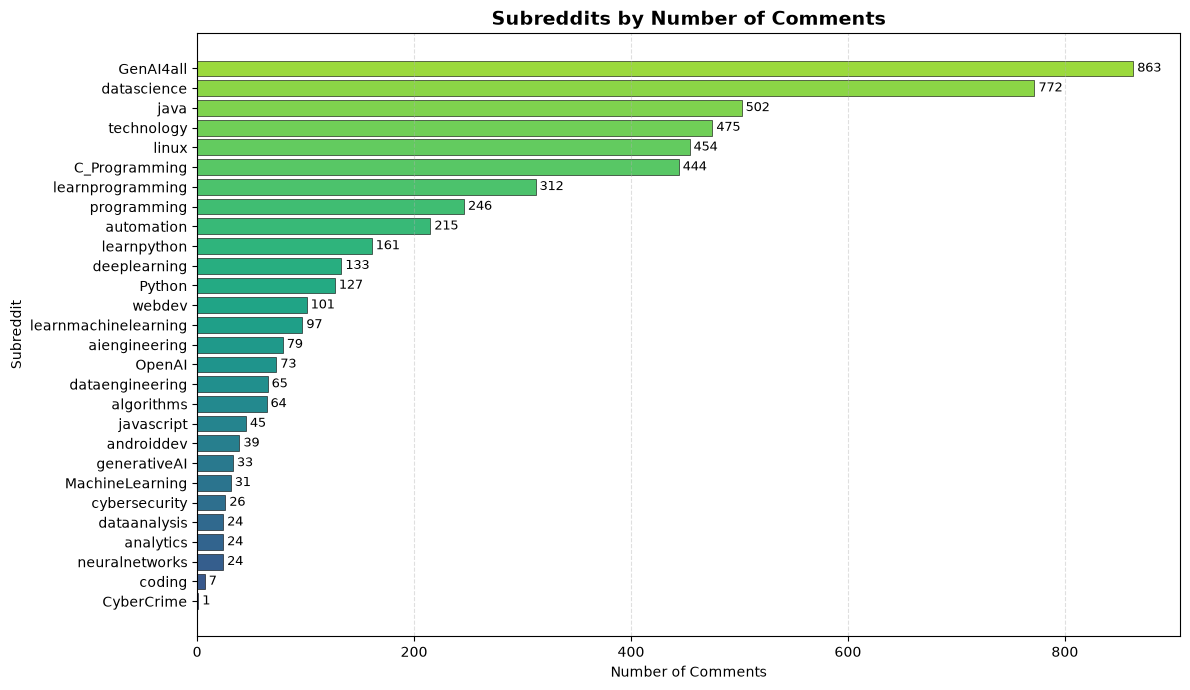

In [13]:
# Plotting the subreddits by number of comments
top_subreddits = (
    subreddit_summary
    .set_index("subreddit")["number_of_comments"]
    .sort_values()
)

plot_colors = plt.cm.viridis(
    np.linspace(0.25, 0.85, len(top_subreddits))
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_subreddits.index,
    top_subreddits.values,
    color=plot_colors,
    edgecolor="black",
    linewidth=0.4
)

for index, value in enumerate(top_subreddits.values):
    plt.text(
        value,
        index,
        f" {value}",
        va="center",
        fontsize=9
    )

plt.title(
    "Subreddits by Number of Comments",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Comments")
plt.ylabel("Subreddit")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

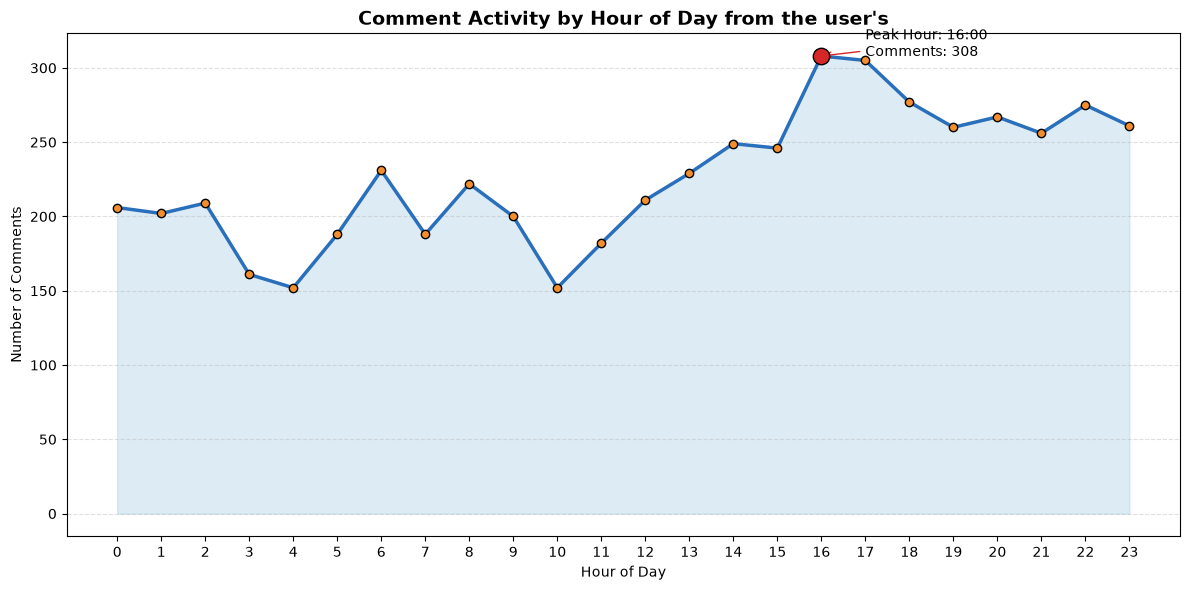

In [14]:
# Plotting comment activity by hour of day from the user's
hourly_comments = (
    reddit_comments
    .assign(comment_hour=reddit_comments["created_datetime"].dt.hour)
    .groupby("comment_hour")["comment_id"]
    .count()
    .reindex(range(24), fill_value=0)
)

peak_hour = hourly_comments.idxmax()
peak_comments = hourly_comments.max()

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_comments.index,
    hourly_comments.values,
    marker="o",
    linewidth=2.5,
    color="#2A6FBB",
    markerfacecolor="#F28E2B",
    markeredgecolor="black"
)

plt.fill_between(
    hourly_comments.index,
    hourly_comments.values,
    color="#9ECAE1",
    alpha=0.35
)

plt.scatter(
    peak_hour,
    peak_comments,
    s=140,
    color="#D62728",
    edgecolor="black",
    zorder=5
)

plt.annotate(
    f"Peak Hour: {peak_hour}:00\nComments: {peak_comments}",
    xy=(peak_hour, peak_comments),
    xytext=(peak_hour + 1, peak_comments),
    arrowprops=dict(arrowstyle="->", color="#D62728"),
    fontsize=10
)

plt.title(
    "Comment Activity by Hour of Day from the user's",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Comments")
plt.xticks(range(24))
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 4. User Reply Network Construction

### 4.1. Creating comment-to-comment reply interactions

In [15]:
# Creating comment-to-comment reply interactions
comment_replies = reddit_comments[
    reddit_comments["reply_target_type"] == "comment"
][
    ["comment_id", "author", "reply_target_id", "subreddit", "created_datetime"]
].reset_index(drop=True)

comment_replies = comment_replies.rename(columns={
    "comment_id": "source_comment_id",
    "author": "source_author"
})

comment_author_lookup = (
    reddit_comments[["comment_id", "author"]]
    .drop_duplicates(subset="comment_id")
    .rename(columns={
        "comment_id": "reply_target_id",
        "author": "target_author"
    })
)

# Merging the comment replies with the author lookup
reply_interactions = comment_replies.merge(
    comment_author_lookup,
    on="reply_target_id",
    how="left"
)

# Removing interactions where the target author is missing and filtering out self-replies
reply_interactions = reply_interactions.dropna(
    subset=["target_author"]
).reset_index(drop=True)

# Removing self-replies where the source author is the same as the target author
reply_interactions = reply_interactions[
    reply_interactions["source_author"] != reply_interactions["target_author"]
].reset_index(drop=True)

display(reply_interactions.head())

,source_comment_id,source_author,reply_target_id,subreddit,created_datetime,target_author
0,mqu9373,syscall_35,mqrvpgx,C_Programming,2025-05-06 05:44:01,EpochVanquisher
1,mqtisqx,nephewtom,mqsjeb4,C_Programming,2025-05-06 02:30:03,TheChief275
2,mqu55w2,mrheosuper,mqsjeb4,C_Programming,2025-05-06 05:09:23,TheChief275
3,mqumd1x,TheChief275,mqu55w2,C_Programming,2025-05-06 07:58:47,mrheosuper
4,mqumko4,TheChief275,mqtisqx,C_Programming,2025-05-06 08:01:04,nephewtom


### 4.2. Creating weighted edge list

In [16]:
# Creating a weighted edge list from the reply interactions
user_reply_edges = (
    reply_interactions
    .groupby(["source_author", "target_author"])
    .agg(
        edge_weight=("source_comment_id", "count"),
        number_of_subreddits=("subreddit", "nunique"),
        first_reply_time=("created_datetime", "min"),
        last_reply_time=("created_datetime", "max")
    )
    .reset_index()
    .sort_values("edge_weight", ascending=False)
)

display(user_reply_edges.head())

,source_author,target_author,edge_weight,number_of_subreddits,first_reply_time,last_reply_time
1435,gabieplease_,kioskinmytemporallob,10,1,2025-05-09 00:33:28,2025-05-09 02:38:49
894,ReallyLargeHamster,Affectionate_Cry4150,9,1,2025-05-09 05:51:42,2025-05-09 08:47:52
1582,kioskinmytemporallob,gabieplease_,9,1,2025-05-09 00:15:31,2025-05-09 02:38:44
63,Affectionate_Cry4150,ReallyLargeHamster,8,1,2025-05-09 05:39:15,2025-05-09 06:44:50
1559,jr735,activedusk,8,1,2025-05-08 22:27:04,2025-05-09 06:27:17


### 4.3. Creating node table with user-level attributes

In [17]:
# Aggregating user-level attributes from the Reddit comments dataset to create a node table
user_reply_nodes = (
    reddit_comments
    .groupby("author")
    .agg(
        total_comments=("comment_id", "count"),
        number_of_subreddits=("subreddit", "nunique"),
        average_score=("score", "mean")
    )
    .reset_index()
)

# Calculating the number of replies sent and received
replies_sent = (
    reply_interactions
    .groupby("source_author")["source_comment_id"]
    .count()
    .reset_index()
    .rename(columns={
        "source_author": "author",
        "source_comment_id": "replies_sent"
    })
)

# Calculating the number of replies received
replies_received = (
    reply_interactions
    .groupby("target_author")["source_comment_id"]
    .count()
    .reset_index()
    .rename(columns={
        "target_author": "author",
        "source_comment_id": "replies_received"
    })
)

# Merging the replies sent and received counts with the user node table
user_reply_nodes = user_reply_nodes.merge(
    replies_sent,
    on="author",
    how="left"
)

user_reply_nodes = user_reply_nodes.merge(
    replies_received,
    on="author",
    how="left"
)

# Filling missing values for replies sent and received
user_reply_nodes["replies_sent"] = (
    user_reply_nodes["replies_sent"]
    .fillna(0)
    .astype(int)
)

user_reply_nodes["replies_received"] = (
    user_reply_nodes["replies_received"]
    .fillna(0)
    .astype(int)
)

# Filtering the user node table
network_users = set(user_reply_edges["source_author"]).union(
    set(user_reply_edges["target_author"])
)

user_reply_nodes = user_reply_nodes[
    user_reply_nodes["author"].isin(network_users)
].reset_index(drop=True)

display(user_reply_nodes.head())

,author,total_comments,number_of_subreddits,average_score,replies_sent,replies_received
0,---AI---,12,1,1.0,12,6
1,--TYGER--,1,1,1.0,1,0
2,--dany--,2,2,1.0,0,1
3,-MagnusBR,1,1,1.0,1,0
4,-Sa-Kage-,1,1,1.0,1,0


### 4.4. Build directed weighted NetworkX graph

In [18]:
# Creating a directed weighted user reply network using NetworkX
user_reply_network = nx.DiGraph()

# Adding nodes to the user reply network with attributes
for _, row in user_reply_nodes.iterrows():
    user_reply_network.add_node(
        row["author"],
        total_comments=int(row["total_comments"]),
        number_of_subreddits=int(row["number_of_subreddits"]),
        average_score=float(row["average_score"]),
        replies_sent=int(row["replies_sent"]),
        replies_received=int(row["replies_received"])
    )

# Adding edges to the user reply network with weights based on the number of replies between users and attributes
for _, row in user_reply_edges.iterrows():
    user_reply_network.add_edge(
        row["source_author"],
        row["target_author"],
        weight=int(row["edge_weight"]),
        number_of_subreddits=int(row["number_of_subreddits"])
    )

# Creating a summary table for the user reply network
user_reply_network_summary = pd.DataFrame([{
    "network_type": "Directed weighted user reply network",
    "nodes_users": user_reply_network.number_of_nodes(),
    "edges_reply_relationships": user_reply_network.number_of_edges(),
    "total_reply_interactions": user_reply_edges["edge_weight"].sum(),
    "density": nx.density(user_reply_network),
    "weakly_connected_components": nx.number_weakly_connected_components(user_reply_network),
    "strongly_connected_components": nx.number_strongly_connected_components(user_reply_network)
}])

display(user_reply_network_summary)

# Saving the user reply network to a GraphML file
nx.write_graphml(
    user_reply_network,
    "../network/user_reply_network.graphml"
)

,network_type,nodes_users,edges_reply_relationships,total_reply_interactions,density,weakly_connected_components,strongly_connected_components
0,Directed weighted user reply network,1692,1991,2366,0.000696,264,1242


## 5. Network Analysis and Community Detection

### 5.1 Helper functions for network analysis

In [19]:
# Function to add inverse weights for path-based centrality measures
def add_inverse_edge_weights(graph, source_weight="weight", target_weight="inverse_weight"):

    for _, _, edge_data in graph.edges(data=True):
        edge_weight = edge_data.get(source_weight, 1)
        edge_data[target_weight] = 1 / edge_weight


# Function to map a NetworkX metric dictionary into the user-level node table
def map_metric_to_nodes(node_table, metric_dictionary):
    
    return node_table["author"].map(metric_dictionary).fillna(0)

### 5.2 Calculating centrality measures

In [20]:
# Adding inverse edge weights to the user reply network
add_inverse_edge_weights(user_reply_network)

in_degree = dict(user_reply_network.in_degree())
out_degree = dict(user_reply_network.out_degree())

# Calculating weighted in-degree
weighted_in_degree = dict(
    user_reply_network.in_degree(weight="weight")
)

# Calculating weighted out-degree
weighted_out_degree = dict(
    user_reply_network.out_degree(weight="weight")
)

# Calculating PageRank scores
pagerank_scores = nx.pagerank(
    user_reply_network,
    weight="weight",
    max_iter=1000
)

# Calculating betweenness centrality scores using inverse weights
betweenness_scores = nx.betweenness_centrality(
    user_reply_network,
    weight="inverse_weight",
    normalized=True
)

# Mapping the calculated network metrics back
network_metrics = user_reply_nodes.assign(
    in_degree=map_metric_to_nodes(user_reply_nodes, in_degree).astype(int),
    out_degree=map_metric_to_nodes(user_reply_nodes, out_degree).astype(int),
    weighted_in_degree=map_metric_to_nodes(user_reply_nodes, weighted_in_degree).astype(int),
    weighted_out_degree=map_metric_to_nodes(user_reply_nodes, weighted_out_degree).astype(int),
    pagerank=map_metric_to_nodes(user_reply_nodes, pagerank_scores),
    betweenness_centrality=map_metric_to_nodes(user_reply_nodes, betweenness_scores)
)

# Sorting the user node table by PageRank scores
network_metrics = (
    network_metrics
    .sort_values("pagerank", ascending=False)
    .reset_index(drop=True)
)

display(network_metrics.head().round(3))

,author,total_comments,number_of_subreddits,average_score,replies_sent,replies_received,in_degree,out_degree,weighted_in_degree,weighted_out_degree,pagerank,betweenness_centrality
0,Affectionate_Cry4150,29,1,1.0,28,35,12,10,35,28,0.007,0.000
1,Desiderantes,2,1,1.0,1,5,5,1,5,1,0.005,0.000
2,Think-Culture-4740,10,1,1.0,6,9,7,5,9,6,0.005,0.000
3,ewouldblock,5,1,28.4,4,14,11,4,14,4,0.005,0.001
4,cochorol,6,1,1.0,1,6,6,1,6,1,0.005,0.000


### 5.3. Detecting communities using Louvain method

In [21]:
# Performing community detection using the Louvain method
undirected_reply_network = user_reply_network.to_undirected()

louvain_communities = nx.community.louvain_communities(
    undirected_reply_network,
    weight="weight",
    seed=42
)

# Mapping the community assignments back to the user node table and the NetworkX graph
community_mapping = {
    user: community_number
    for community_number, community_users in enumerate(louvain_communities, start=1)
    for user in community_users
}

network_metrics["community"] = (
    network_metrics["author"]
    .map(community_mapping)
)

# Adding community assignments as node attributes in the NetworkX graph
nx.set_node_attributes(
    user_reply_network,
    community_mapping,
    "community"
)

### 5.4. Evaluating Louvain communities

In [22]:
# Calculating modularity score for the detected communities
modularity_score = nx.community.modularity(
    undirected_reply_network,
    louvain_communities,
    weight="weight"
)

# Creating a summary table for the detected communities with key metrics for each community
community_summary = (
    network_metrics
    .groupby("community")
    .agg(
        number_of_users=("author", "count"),
        total_comments=("total_comments", "sum"),
        total_replies_sent=("replies_sent", "sum"),
        total_replies_received=("replies_received", "sum"),
        average_pagerank=("pagerank", "mean"),
        average_betweenness=("betweenness_centrality", "mean")
    )
    .reset_index()
    .sort_values("number_of_users", ascending=False)
)

# Creating a summary table for the overall network analysis results
network_analysis_summary = pd.DataFrame([{
    "community_detection_algorithm": "Louvain method",
    "number_of_detected_communities": len(louvain_communities),
    "modularity_score": modularity_score,
    "largest_community_size": community_summary["number_of_users"].max(),
    "smallest_community_size": community_summary["number_of_users"].min()
}])

display(network_analysis_summary)


,community_detection_algorithm,number_of_detected_communities,modularity_score,largest_community_size,smallest_community_size
0,Louvain method,278,0.953095,96,2


In [23]:
# Displaying the summary of detected communities with key metrics for each community
display(community_summary.head().round(3))

,community,number_of_users,total_comments,total_replies_sent,total_replies_received,average_pagerank,average_betweenness
183,184,96,197,154,155,0.001,0.0
88,89,87,238,179,179,0.001,0.0
50,51,85,222,125,117,0.001,0.0
160,161,73,167,132,132,0.001,0.0
14,15,62,138,106,105,0.001,0.0


### 5.5. Identifying important user roles

In [24]:
# Identifying the top users using different network measures
top_replied_users = (
    network_metrics
    .sort_values("weighted_in_degree", ascending=False)
    .head(10)
    [["author", "weighted_in_degree"]]
)

top_replying_users = (
    network_metrics
    .sort_values("weighted_out_degree", ascending=False)
    .head(10)
    [["author", "weighted_out_degree"]]
)

top_bridge_users = (
    network_metrics
    .sort_values("betweenness_centrality", ascending=False)
    .head(10)
    [["author", "betweenness_centrality"]]
)

top_influential_users = (
    network_metrics
    .sort_values("pagerank", ascending=False)
    .head(10)
    [["author", "pagerank"]]
)

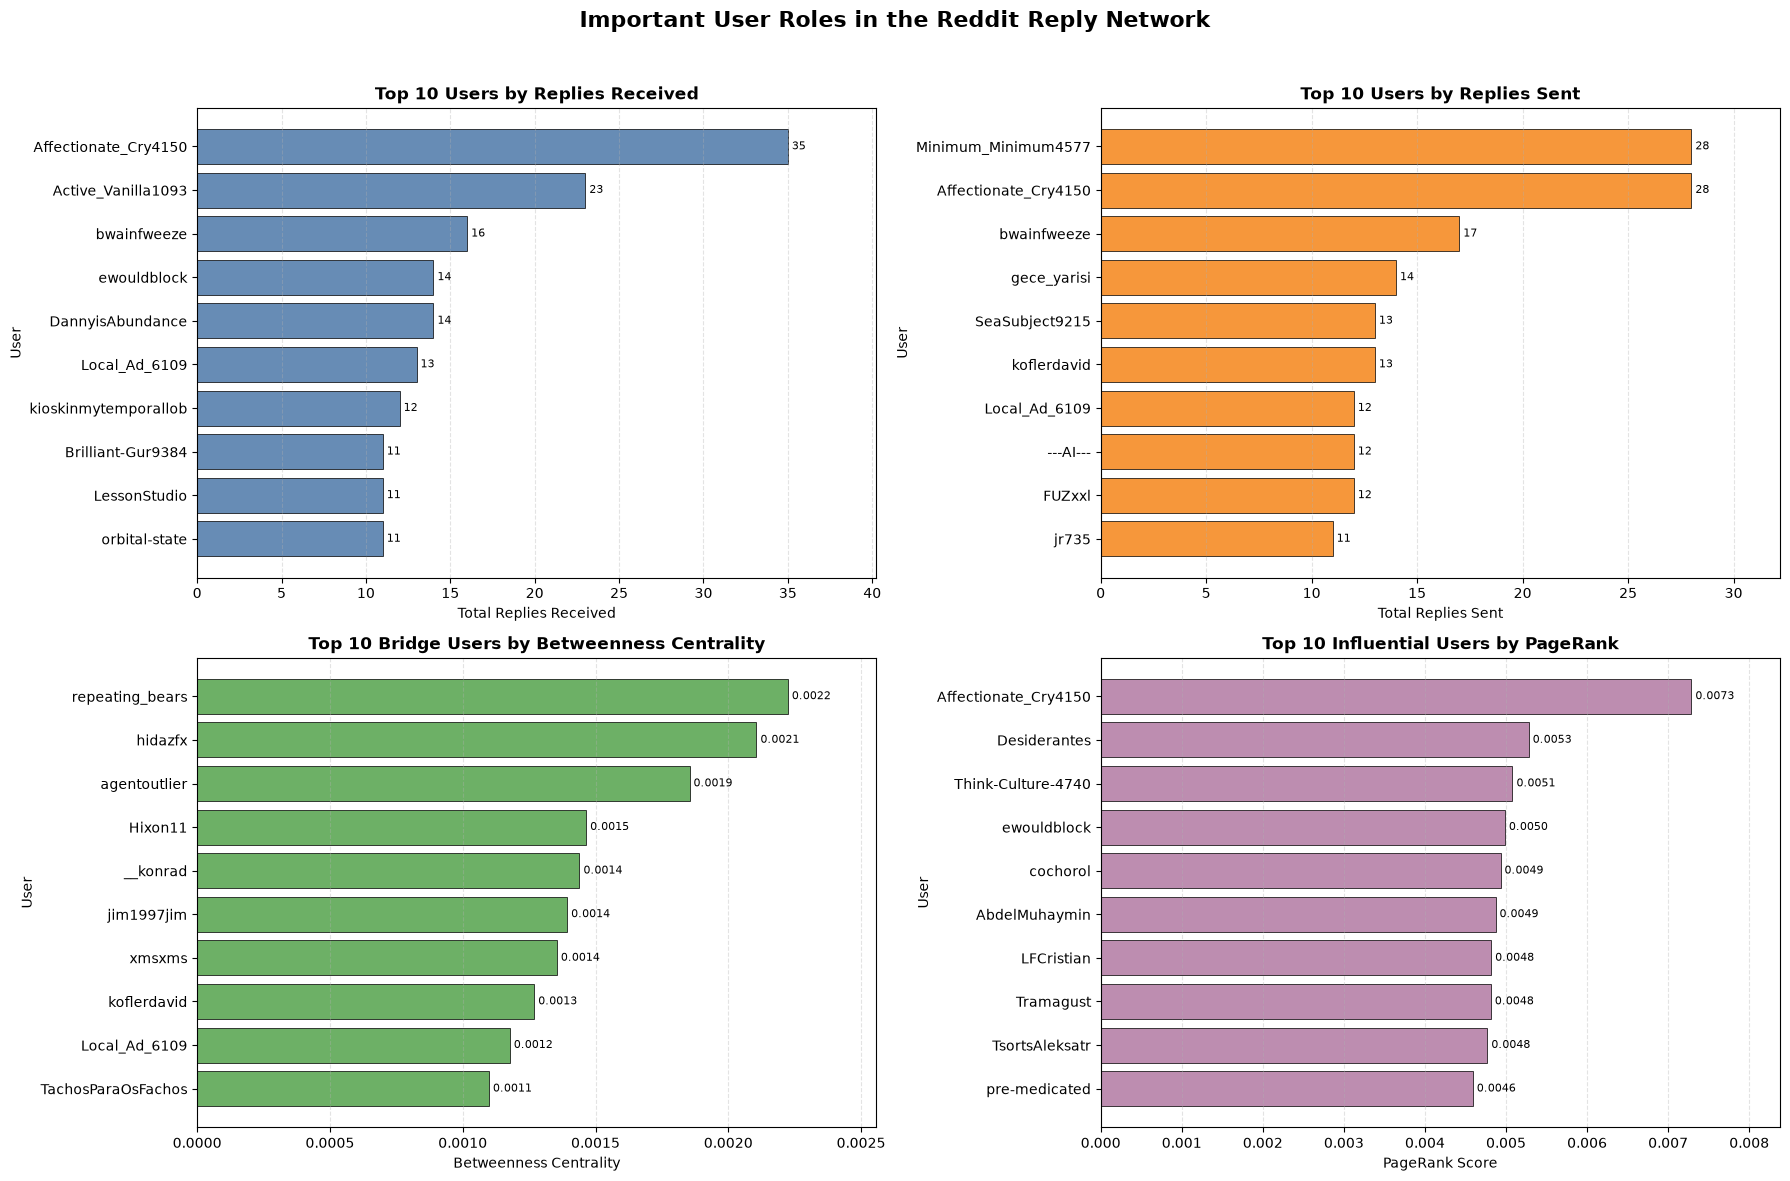

In [25]:
# Plotting a combined plot for the main user roles based on the calculated network metrics

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

plot_colors = {
    "replied": "#4C78A8",
    "replying": "#F58518",
    "bridge": "#54A24B",
    "influential": "#B279A2"
}


def plot_user_role_bar_chart(axis, data, user_column, value_column, title, xlabel, color):

    plot_data = data.sort_values(value_column, ascending=True)

    bars = axis.barh(
        plot_data[user_column],
        plot_data[value_column],
        color=color,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.85
    )

    for bar in bars:
        value = bar.get_width()

        axis.text(
            value,
            bar.get_y() + bar.get_height() / 2,
            f" {value:.4f}" if value < 1 else f" {int(value)}",
            va="center",
            fontsize=8
        )

    axis.set_title(title, fontsize=12, fontweight="bold")
    axis.set_xlabel(xlabel)
    axis.set_ylabel("User")
    axis.grid(axis="x", linestyle="--", alpha=0.35)
    axis.margins(x=0.15)


# Plot for top users by replies received
plot_user_role_bar_chart(
    axis=axes[0],
    data=top_replied_users,
    user_column="author",
    value_column="weighted_in_degree",
    title="Top 10 Users by Replies Received",
    xlabel="Total Replies Received",
    color=plot_colors["replied"]
)

# Plot for top users by replies sent
plot_user_role_bar_chart(
    axis=axes[1],
    data=top_replying_users,
    user_column="author",
    value_column="weighted_out_degree",
    title="Top 10 Users by Replies Sent",
    xlabel="Total Replies Sent",
    color=plot_colors["replying"]
)

# Plot for top bridge users by betweenness centrality
plot_user_role_bar_chart(
    axis=axes[2],
    data=top_bridge_users,
    user_column="author",
    value_column="betweenness_centrality",
    title="Top 10 Bridge Users by Betweenness Centrality",
    xlabel="Betweenness Centrality",
    color=plot_colors["bridge"]
)

# Plot for top influential users by PageRank scores
plot_user_role_bar_chart(
    axis=axes[3],
    data=top_influential_users,
    user_column="author",
    value_column="pagerank",
    title="Top 10 Influential Users by PageRank",
    xlabel="PageRank Score",
    color=plot_colors["influential"]
)

plt.suptitle(
    "Important User Roles in the Reddit Reply Network",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 5.6. Interpreting Communities

In [26]:
# Analyzing the detected communities
comments_with_community = reddit_comments.merge(
    network_metrics[["author", "community"]],
    on="author",
    how="inner"
)

# Creating a summary table for the communities
community_subreddit_summary = (
    comments_with_community
    .groupby(["community", "subreddit"])
    .agg(
        number_of_comments=("comment_id", "count"),
        number_of_users=("author", "nunique")
    )
    .reset_index()
    .sort_values(["community", "number_of_comments"], ascending=[True, False])
)

# Identifying the dominant subreddit
dominant_subreddit_per_community = (
    community_subreddit_summary
    .drop_duplicates(subset="community")
    .rename(columns={
        "subreddit": "dominant_subreddit",
        "number_of_comments": "dominant_subreddit_comments",
        "number_of_users": "dominant_subreddit_users"
    })
    [
        [
            "community",
            "dominant_subreddit",
            "dominant_subreddit_comments",
            "dominant_subreddit_users"
        ]
    ]
)

# Identifying the top users in each community based on PageRank scores
top_users_per_community = (
    network_metrics
    .sort_values(["community", "pagerank"], ascending=[True, False])
    .groupby("community")
    .head(3)
    .groupby("community")["author"]
    .apply(lambda users: ", ".join(users))
    .reset_index(name="top_users")
)

top_10_communities = community_summary.head(10)["community"]

community_documents = (
    comments_with_community[
        comments_with_community["community"].isin(top_10_communities)
    ]
    .groupby("community")["clean_body"]
    .apply(lambda comments: " ".join(comments))
    .reset_index()
)

# Using TF-IDF vectorization to extract the top keywords for each community based
community_tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.90,
    min_df=1,
    ngram_range=(1, 2),
    token_pattern=r"(?u)[A-Za-z0-9_+#]{2,}"
)

community_tfidf_matrix = community_tfidf_vectorizer.fit_transform(
    community_documents["clean_body"]
)

community_tfidf_terms = community_tfidf_vectorizer.get_feature_names_out()

community_topic_rows = []

for row_index, community_id in enumerate(community_documents["community"]):
    tfidf_scores = community_tfidf_matrix[row_index].toarray().flatten()
    top_term_indexes = tfidf_scores.argsort()[-10:][::-1]

    top_keywords = [
        community_tfidf_terms[index]
        for index in top_term_indexes
        if tfidf_scores[index] > 0
    ]

    community_topic_rows.append({
        "community": community_id,
        "top_keywords": ", ".join(top_keywords)
    })

# Creating the DataFrame for the community topics with the top keywords for each community
community_topics = pd.DataFrame(community_topic_rows)

# Merging the community summary
community_interpretation = (
    community_summary
    .merge(dominant_subreddit_per_community, on="community", how="left")
    .merge(top_users_per_community, on="community", how="left")
    .merge(community_topics, on="community", how="left")
    .sort_values("number_of_users", ascending=False)
)

# Creating the community label
community_interpretation["community_label"] = (
    "Community "
    + community_interpretation["community"].astype(str)
    + " - "
    + community_interpretation["dominant_subreddit"].astype(str)
    + " interaction group"
)

# Reordering the columns for better readability in the final community interpretation table
community_interpretation = community_interpretation[
    [
        "community",
        "community_label",
        "number_of_users",
        "total_comments",
        "total_replies_sent",
        "total_replies_received",
        "dominant_subreddit",
        "dominant_subreddit_comments",
        "dominant_subreddit_users",
        "top_users",
        "top_keywords",
        "average_pagerank",
        "average_betweenness"
    ]
]

display(community_interpretation.head())

,community,community_label,number_of_users,total_comments,total_replies_sent,total_replies_received,dominant_subreddit,dominant_subreddit_comments,dominant_subreddit_users,top_users,top_keywords,average_pagerank,average_betweenness
0,184,Community 184 - programming interaction group,96,197,154,155,programming,166,86,"pre-medicated, LessonStudio, Local_Ad_6109","100k, url, handle, urls, aws, database, ve, code, tables, distributed",0.000608,0.000108
1,89,Community 89 - java interaction group,87,238,179,179,java,228,85,"ewouldblock, Hixon11, Diligent_End8130","java, code, python, string, optional, zgc, language, null, json, hashcode",0.000720,0.000165
2,51,Community 51 - GenAI4all interaction group,85,222,125,117,GenAI4all,222,85,"Active_Vanilla1093, Timely-Description24, samy_the_samy","ai, chip, ironwood, doctor, google, ai tool, content, haha, sounds, totally",0.000507,0.000013
3,161,Community 161 - linux interaction group,73,167,132,132,linux,167,73,"Desiderantes, TsortsAleksatr, reeses_boi","linux, ventoy, windows, usb, distro, roblox, ubuntu, install, boot, iso",0.000666,0.000009
4,15,Community 15 - java interaction group,62,138,106,105,java,136,62,"repeating_bears, AstronautDifferent19, jim1997jim","memory, java, scala, zgc, heap, xx, code, container, data structures, operation",0.000587,0.000135


### 5.7. Network Visualization

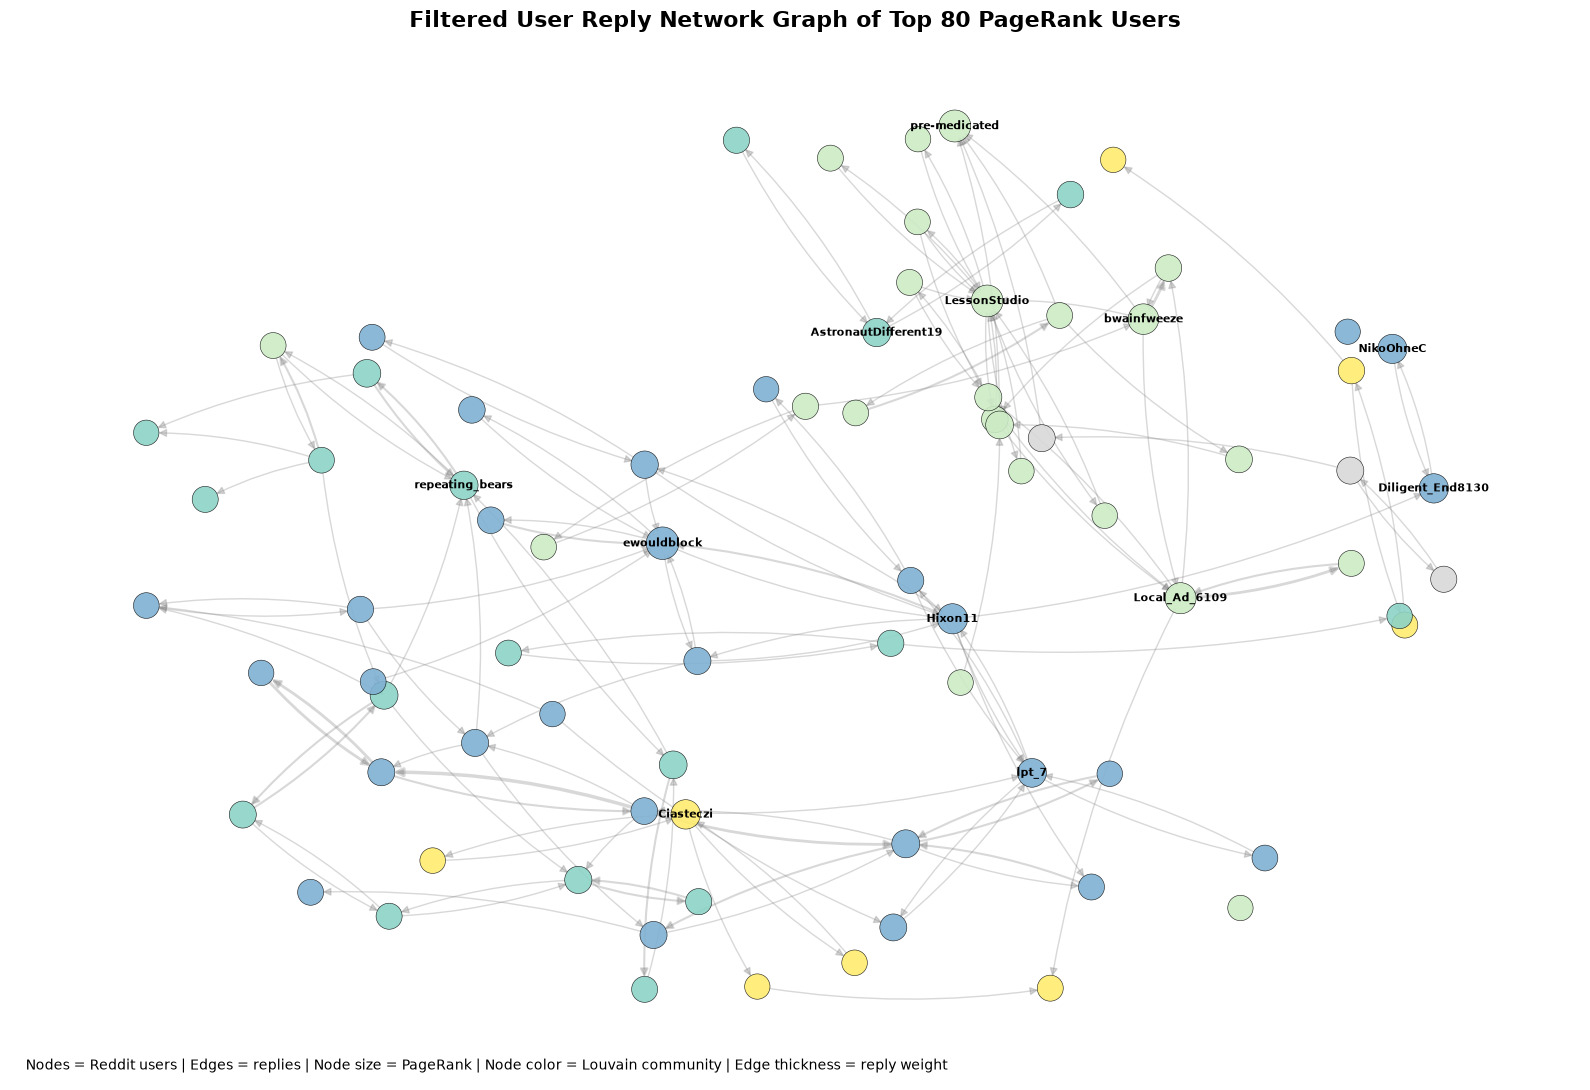

In [27]:
# Visualizing the user reply network graph
largest_component_nodes = max(
    nx.weakly_connected_components(user_reply_network),
    key=len
)

largest_component = user_reply_network.subgraph(largest_component_nodes)

# Identifying the top 80 users in the largest component based on PageRank scores for visualization
top_network_users = (
    network_metrics[
        network_metrics["author"].isin(largest_component.nodes())
    ]
    .sort_values("pagerank", ascending=False)
    .head(80)["author"]
    .tolist()
)


network_graph_plot = user_reply_network.subgraph(top_network_users)

network_layout = nx.spring_layout(
    network_graph_plot,
    seed=42,
    k=0.8,
    iterations=100
)

# Mapping node sizes based on PageRank scores and scaling
node_sizes = [
    300 + network_metrics.loc[
        network_metrics["author"] == user,
        "pagerank"
    ].values[0] * 50000
    for user in network_graph_plot.nodes()
]

# Mapping node colors based on Louvain community assignments
node_colors = [
    network_metrics.loc[
        network_metrics["author"] == user,
        "community"
    ].values[0]
    for user in network_graph_plot.nodes()
]

edge_widths = [
    0.5 + network_graph_plot[source][target].get("weight", 1) * 0.5
    for source, target in network_graph_plot.edges()
]

# Identifying the top users for labeling
top_label_users = (
    network_metrics[
        network_metrics["author"].isin(network_graph_plot.nodes())
    ]
    .sort_values("pagerank", ascending=False)
    .head(12)["author"]
    .tolist()
)

# Creating node labels only for the top users to avoid cluttering the graph
node_labels = {
    user: user if user in top_label_users else ""
    for user in network_graph_plot.nodes()
}

# Plotting the user reply network graph with custom styling for nodes, edges, and labels
plt.figure(figsize=(16, 11))
plt.gca().set_facecolor("#F7F7F7")

nx.draw_networkx_nodes(
    network_graph_plot,
    network_layout,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.Set3,
    alpha=0.90,
    edgecolors="black",
    linewidths=0.4
)

nx.draw_networkx_edges(
    network_graph_plot,
    network_layout,
    width=edge_widths,
    edge_color="#7F7F7F",
    alpha=0.30,
    arrows=True,
    arrowsize=12,
    connectionstyle="arc3,rad=0.08"
)

nx.draw_networkx_labels(
    network_graph_plot,
    network_layout,
    labels=node_labels,
    font_size=8,
    font_weight="bold"
)

plt.title(
    "Filtered User Reply Network Graph of Top 80 PageRank Users",
    fontsize=16,
    fontweight="bold"
)

plt.text(
    0.01,
    0.01,
    "Nodes = Reddit users | Edges = replies | Node size = PageRank | Node color = Louvain community | Edge thickness = reply weight",
    transform=plt.gca().transAxes,
    fontsize=10
)

plt.axis("off")
plt.tight_layout()
plt.show()

## 6. NLP, Sentiment Analysis, and Topic Modelling

### 6.1. Helper functions for NLP analysis

In [28]:
# Function to classify sentiment based on VADER compound scores
def classify_sentiment(score):

    if score >= 0.05:
        return "Positive"
    if score <= -0.05:
        return "Negative"
    return "Neutral"

# Function to calculate the percentage of a sentiment label inside a grouped series
def sentiment_percentage(labels, target_label):

    return (labels == target_label).mean() * 100

# Function to create a word-frequency dictionary from topic-word weights
def get_topic_word_frequencies(topic_weights, vocabulary_terms, top_n=80):

    top_word_indexes = topic_weights.argsort()[-top_n:][::-1]

    return {
        vocabulary_terms[word_index]: topic_weights[word_index]
        for word_index in top_word_indexes
        if topic_weights[word_index] > 0
    }

# Function to create a sentiment summary table showing sentiment counts, percentages, and average sentiment score
def create_sentiment_summary(data, label_column, score_column, model_name):
    """
    Create a sentiment summary table showing sentiment counts,
    percentages, and average sentiment score.
    """

    sentiment_summary = (
        data
        .groupby(label_column)
        .agg(
            number_of_comments=("comment_id", "count"),
            average_sentiment_score=(score_column, "mean")
        )
        .reset_index()
        .rename(columns={label_column: "sentiment_label"})
    )

    sentiment_summary["percentage"] = (
        sentiment_summary["number_of_comments"] / len(data) * 100
    )

    sentiment_summary = (
        sentiment_summary
        .set_index("sentiment_label")
        .reindex(["Positive", "Neutral", "Negative"])
        .fillna(0)
        .reset_index()
    )

    sentiment_summary["model"] = model_name

    sentiment_summary = sentiment_summary[
        [
            "model",
            "sentiment_label",
            "number_of_comments",
            "percentage",
            "average_sentiment_score"
        ]
    ]

    return sentiment_summary

# Function to normalize RoBERTa model labels into readable sentiment labels
def normalize_roberta_label(raw_label):
    """
    Convert RoBERTa model labels into readable sentiment labels.
    """

    raw_label = str(raw_label).lower()

    if raw_label in ["label_0", "negative"]:
        return "Negative"
    if raw_label in ["label_1", "neutral"]:
        return "Neutral"
    if raw_label in ["label_2", "positive"]:
        return "Positive"

    return raw_label.title()

### 6.2. Preparing NLP Resources and Comment-Level Dataset

In [29]:
# Preparing the data for NLP analysis by merging the Reddit comments with the community assignments and creating a clean text column for NLP processing

# Creating a list of English stop words
english_stop_words = sorted(set(stopwords.words("english")))

author_community_lookup = (
    network_metrics[["author", "community"]]
    .drop_duplicates(subset="author")
)

nlp_comments = reddit_comments.merge(
    author_community_lookup,
    on="author",
    how="left"
)

nlp_comments["body"] = nlp_comments["body"].astype("string").fillna("")
nlp_comments["clean_body"] = nlp_comments["clean_body"].astype("string").fillna("")

nlp_comments = nlp_comments[
    nlp_comments["clean_body"].str.strip() != ""
].reset_index(drop=True)

# Creating a summary table for the NLP data
nlp_data_summary = pd.DataFrame([{
    "comments_available_for_nlp": len(nlp_comments),
    "unique_subreddits": nlp_comments["subreddit"].nunique(),
    "unique_authors": nlp_comments["author"].nunique(),
    "comments_with_louvain_community": nlp_comments["community"].notna().sum()
}])

display(nlp_data_summary)

,comments_available_for_nlp,unique_subreddits,unique_authors,comments_with_louvain_community
0,5437,28,3103,3764


### 6.3. Sentiment Analysis Using VADER and RoBERTa

#### 6.3.1. VADER Sentiment Analysis

In [30]:
# VADER is used as the baseline sentiment model
vader_analyzer = SentimentIntensityAnalyzer()

nlp_comments["vader_sentiment_score"] = nlp_comments["body"].apply(
    lambda text: vader_analyzer.polarity_scores(str(text))["compound"]
)

nlp_comments["vader_sentiment_label"] = nlp_comments["vader_sentiment_score"].apply(
    classify_sentiment
)

# Table for VADER sentiment results
vader_sentiment_summary = create_sentiment_summary(
    data=nlp_comments,
    label_column="vader_sentiment_label",
    score_column="vader_sentiment_score",
    model_name="VADER"
)

display(vader_sentiment_summary.round(3))

,model,sentiment_label,number_of_comments,percentage,average_sentiment_score
0,VADER,Positive,2998,55.141,0.580
1,VADER,Neutral,1195,21.979,0.000
2,VADER,Negative,1244,22.880,-0.455


#### 6.3.2. RoBERTa Sentiment Analysis

In [31]:
# RoBERTa is used as the main sentiment model for the final sentiment analysis

# Suppressing the warnings and setting logging levels to reduce noise during RoBERTa sentiment analysis
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
transformers_logging.set_verbosity_error()

# Loading the RoBERTa model and tokenizer
roberta_model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

roberta_analyzer = pipeline(
    "sentiment-analysis",
    model=roberta_model_name,
    tokenizer=roberta_model_name,
    top_k=None
)

comment_texts = nlp_comments["body"].astype(str).tolist()
batch_size = 16
roberta_results = []

for start_index in range(0, len(comment_texts), batch_size):
    batch_texts = comment_texts[start_index:start_index + batch_size]

    batch_results = roberta_analyzer(
        batch_texts,
        truncation=True,
        max_length=512
    )

    roberta_results.extend(batch_results)


# Extracting RoBERTa sentiment labels, confidence scores, and numeric sentiment scores
roberta_sentiment_rows = []

for result in roberta_results:

    if isinstance(result, dict):
        result = [result]

    label_scores = {}

    for label_score in result:
        sentiment_label = normalize_roberta_label(label_score["label"])
        label_scores[sentiment_label] = label_score["score"]

    predicted_label = max(label_scores, key=label_scores.get)

    roberta_sentiment_rows.append({
        "roberta_sentiment_label": predicted_label,
        "roberta_sentiment_score": (
            label_scores.get("Positive", 0)
            - label_scores.get("Negative", 0)
        )
})

roberta_sentiment_df = pd.DataFrame(roberta_sentiment_rows)

# Adding RoBERTa sentiment results to the NLP comments DataFrame
nlp_comments = nlp_comments.reset_index(drop=True)

for column in roberta_sentiment_df.columns:
    nlp_comments[column] = roberta_sentiment_df[column]

# Table for RoBERTa sentiment results
roberta_sentiment_summary = create_sentiment_summary(
    data=nlp_comments,
    label_column="roberta_sentiment_label",
    score_column="roberta_sentiment_score",
    model_name="RoBERTa"
)

display(roberta_sentiment_summary.round(3))


# Using RoBERTa as the best model for the final sentiment analysis
nlp_comments["sentiment_label"] = nlp_comments["roberta_sentiment_label"]
nlp_comments["sentiment_score"] = nlp_comments["roberta_sentiment_score"]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 21263.50it/s]


,model,sentiment_label,number_of_comments,percentage,average_sentiment_score
0,RoBERTa,Positive,1031,18.963,0.744
1,RoBERTa,Neutral,2793,51.370,-0.034
2,RoBERTa,Negative,1613,29.667,-0.679


### 6.4. Comparing VADER and RoBERTa Sentiment Results

In [32]:
# Creating a combined table for sentiment comparison between VADER and RoBERTa models to analyze the differences in sentiment classification results between the two models

sentiment_comparison = pd.concat(
    [
        vader_sentiment_summary[["model", "sentiment_label", "percentage"]],
        roberta_sentiment_summary[["model", "sentiment_label", "percentage"]]
    ],
    ignore_index=True
)

sentiment_order = ["Positive", "Neutral", "Negative"]
model_order = ["VADER", "RoBERTa"]

sentiment_comparison_plot = (
    sentiment_comparison
    .pivot(index="sentiment_label", columns="model", values="percentage")
    .reindex(sentiment_order)
    .reindex(columns=model_order)
)

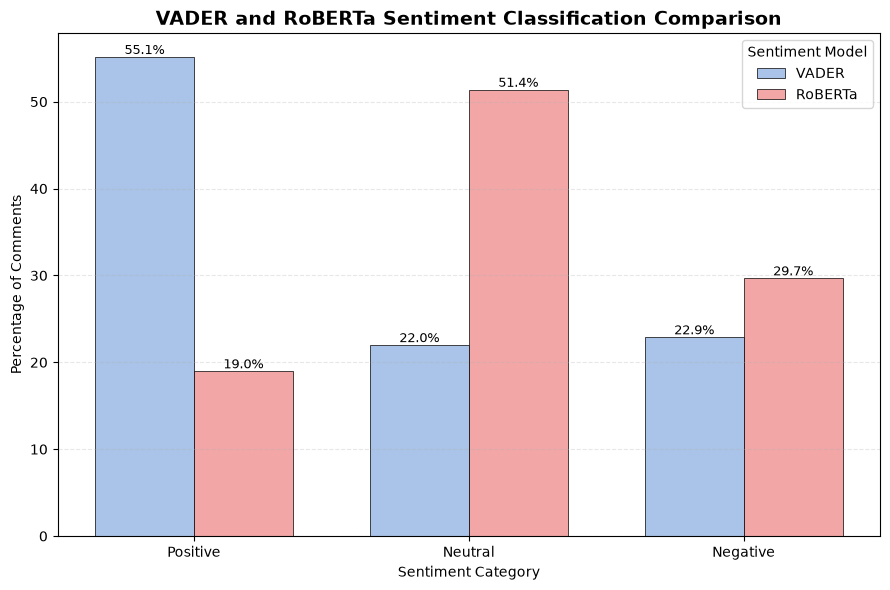

In [33]:
# Plotting the comparison of sentiment classification results between VADER and RoBERTa

comparison_colors = {
    "VADER": "#A9C4E8",
    "RoBERTa": "#F2A6A6"
}

x_positions = np.arange(len(sentiment_order))
bar_width = 0.36

plt.figure(figsize=(9, 6))

for model_index, model_name in enumerate(model_order):
    bar_positions = x_positions + (model_index - 0.5) * bar_width

    bars = plt.bar(
        bar_positions,
        sentiment_comparison_plot[model_name],
        width=bar_width,
        label=model_name,
        color=comparison_colors[model_name],
        edgecolor="black",
        linewidth=0.5
    )

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.title(
    "VADER and RoBERTa Sentiment Classification Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Sentiment Category")
plt.ylabel("Percentage of Comments")
plt.xticks(x_positions, sentiment_order)
plt.legend(title="Sentiment Model")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 6.5. Sentiment by Subreddit Using RoBERTa

In [34]:
# Analyzing sentiment by subreddit using RoBERTa as the primary sentiment model

# Identifying the top subreddits
top_subreddits_for_sentiment = (
    nlp_comments["subreddit"]
    .value_counts()
    .index
)

# Creating a summary table for subreddit sentiment analysis showing the average sentiment score and the percentage of each sentiment label for the top subreddits
subreddit_sentiment_summary = (
    nlp_comments[
        nlp_comments["subreddit"].isin(top_subreddits_for_sentiment)
    ]
    .groupby("subreddit")
    .agg(
        number_of_comments=("comment_id", "count"),
        average_sentiment=("sentiment_score", "mean"),
        positive_percentage=("sentiment_label", lambda labels: sentiment_percentage(labels, "Positive")),
        neutral_percentage=("sentiment_label", lambda labels: sentiment_percentage(labels, "Neutral")),
        negative_percentage=("sentiment_label", lambda labels: sentiment_percentage(labels, "Negative"))
    )
    .reset_index()
    .sort_values("average_sentiment", ascending=False)
)

display(subreddit_sentiment_summary.round(3))


,subreddit,number_of_comments,average_sentiment,positive_percentage,neutral_percentage,negative_percentage
1,CyberCrime,1,0.900,100.000,0.000,0.000
11,coding,7,0.309,42.857,42.857,14.286
8,analytics,24,0.286,37.500,50.000,12.500
17,generativeAI,33,0.281,48.485,39.394,12.121
10,automation,215,0.251,36.744,53.953,9.302
6,aiengineering,79,0.138,26.582,60.759,12.658
24,neuralnetworks,24,0.135,29.167,62.500,8.333
13,dataanalysis,24,0.094,29.167,58.333,12.500
14,dataengineering,65,0.064,16.923,72.308,10.769
20,learnmachinelearning,97,0.049,25.773,51.546,22.680


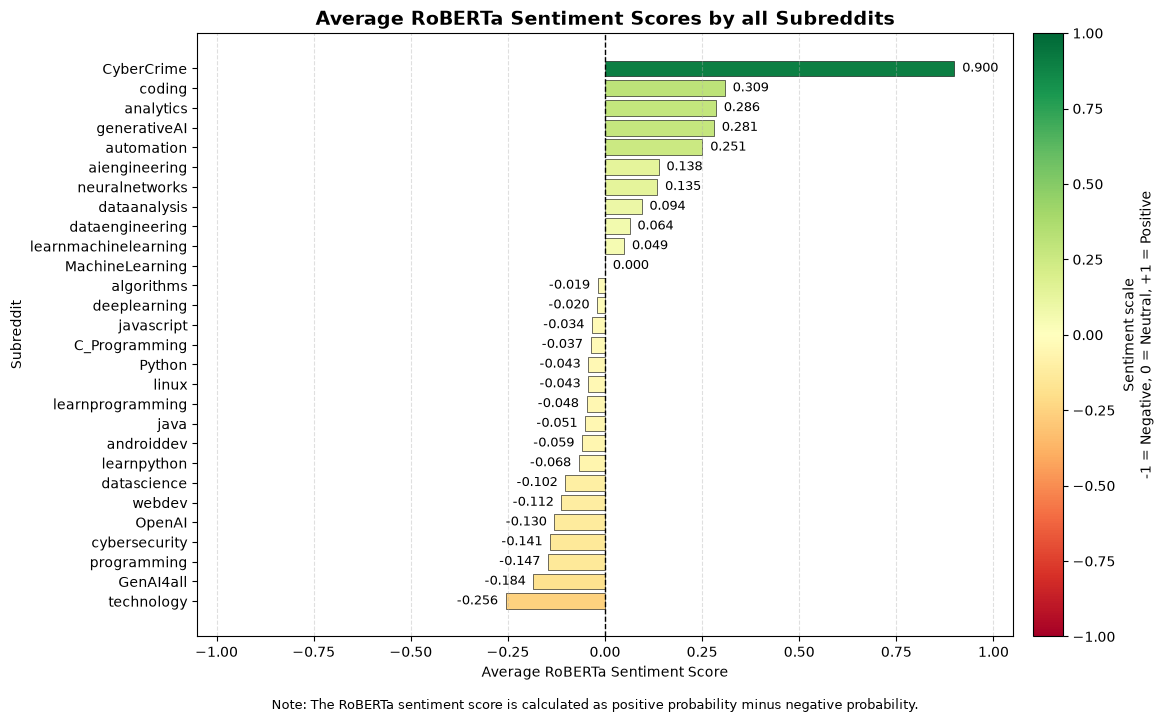

In [35]:
# Plotting the average RoBERTa sentiment score by top subreddits

plot_subreddit_sentiment = (
    subreddit_sentiment_summary
    .sort_values("average_sentiment")
)

# RoBERTa sentiment score interpretation:
# Positive probability - Negative probability
# -1 = strongly negative, 0 = neutral/mixed, +1 = strongly positive
sentiment_normalizer = TwoSlopeNorm(
    vmin=-1,
    vcenter=0,
    vmax=1
)

plot_colors = plt.cm.RdYlGn(
    sentiment_normalizer(plot_subreddit_sentiment["average_sentiment"])
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    plot_subreddit_sentiment["subreddit"],
    plot_subreddit_sentiment["average_sentiment"],
    color=plot_colors,
    edgecolor="black",
    linewidth=0.4
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color="black"
)

# Adding the score values at the end of each bar
for bar in bars:
    score = bar.get_width()
    y_position = bar.get_y() + bar.get_height() / 2

    if score >= 0:
        text_position = score + 0.02
        horizontal_alignment = "left"
    else:
        text_position = score - 0.02
        horizontal_alignment = "right"

    plt.text(
        text_position,
        y_position,
        f"{score:.3f}",
        va="center",
        ha=horizontal_alignment,
        fontsize=9
    )

plt.title(
    "Average RoBERTa Sentiment Scores by all Subreddits",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average RoBERTa Sentiment Score")
plt.ylabel("Subreddit")
plt.xlim(-1.05, 1.05)
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Adding colorbar to explain sentiment color scale
sentiment_colorbar = plt.cm.ScalarMappable(
    cmap=plt.cm.RdYlGn,
    norm=sentiment_normalizer
)

sentiment_colorbar.set_array([])

colorbar = plt.colorbar(
    sentiment_colorbar,
    ax=plt.gca(),
    pad=0.02
)

colorbar.set_label(
    "Sentiment scale\n-1 = Negative, 0 = Neutral, +1 = Positive",
    fontsize=10
)

plt.figtext(
    0.5,
    -0.02,
    "Note: The RoBERTa sentiment score is calculated as positive probability minus negative probability.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

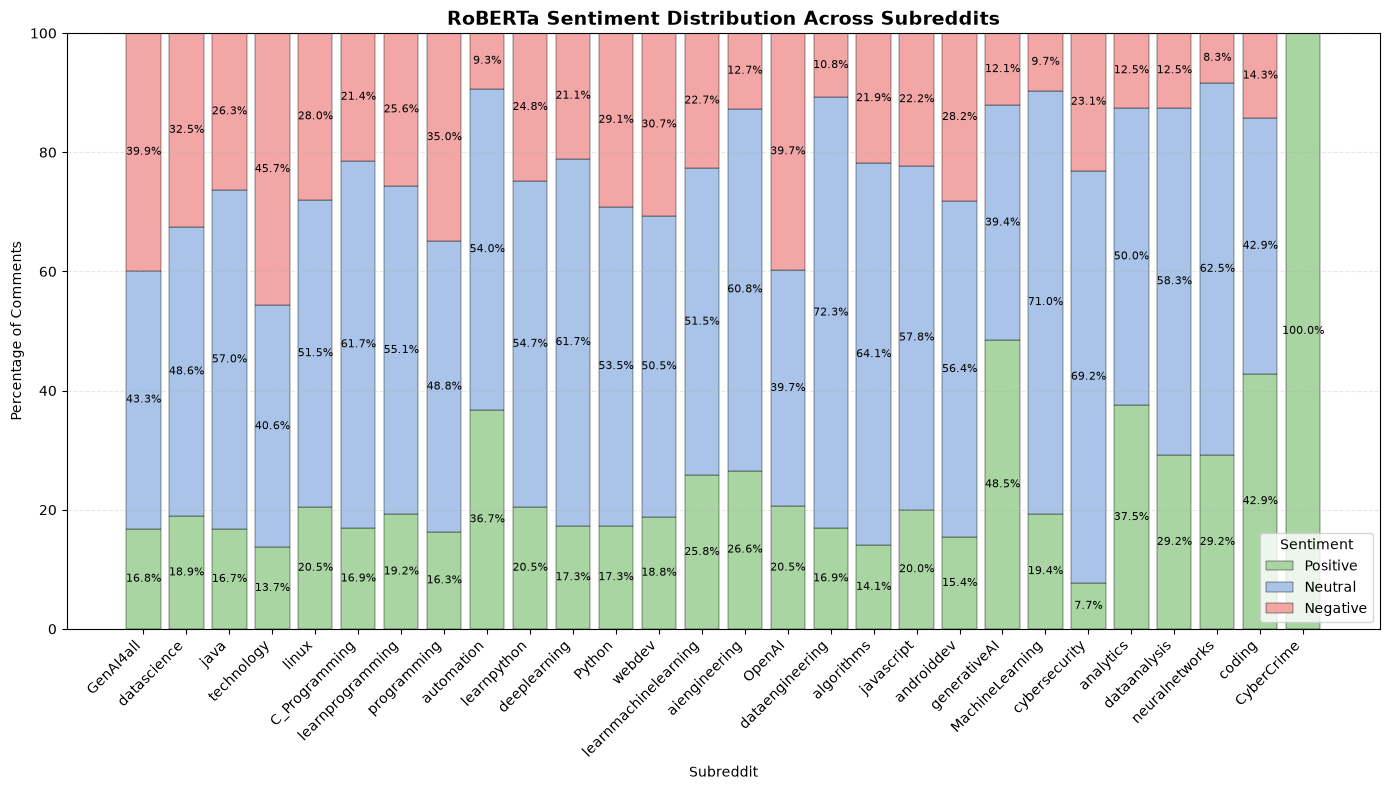

In [36]:
# Plotting the sentiment distribution across all subreddits using RoBERTa labels
subreddit_sentiment_distribution = (
    nlp_comments
    .groupby(["subreddit", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Positive", "Neutral", "Negative"], fill_value=0)
)

subreddit_sentiment_distribution = (
    subreddit_sentiment_distribution
    .loc[subreddit_sentiment_distribution.sum(axis=1).sort_values(ascending=False).index]
)

subreddit_sentiment_percentage = (
    subreddit_sentiment_distribution
    .div(subreddit_sentiment_distribution.sum(axis=1), axis=0)
    .mul(100)
)

sentiment_colors = {
    "Positive": "#A8D5A2",
    "Neutral": "#A9C4E8",
    "Negative": "#F2A6A6"
}

plt.figure(figsize=(14, 8))

bottom_values = np.zeros(len(subreddit_sentiment_percentage))

for sentiment_label in ["Positive", "Neutral", "Negative"]:
    values = subreddit_sentiment_percentage[sentiment_label]

    plt.bar(
        subreddit_sentiment_percentage.index,
        values,
        bottom=bottom_values,
        color=sentiment_colors[sentiment_label],
        edgecolor="black",
        linewidth=0.3,
        label=sentiment_label
    )

    # Adding percentage labels inside the bars
    for index, value in enumerate(values):
        if value >= 5:
            plt.text(
                index,
                bottom_values[index] + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8
            )

    bottom_values += values.values

plt.title(
    "RoBERTa Sentiment Distribution Across Subreddits",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Subreddit")
plt.ylabel("Percentage of Comments")
plt.ylim(0, 100)
plt.legend(title="Sentiment")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=45, ha="right")


plt.tight_layout()
plt.show()

### 6.6. Sentiment Analysis by Louvain Community Using RoBERTa

In [37]:
# Analyzing RoBERTa sentiment scores and sentiment label distributions by Louvain community

# Creating a summary table for community sentiment analysis
community_sentiment_data = (
    nlp_comments
    .dropna(subset=["community"])
    .reset_index(drop=True)
)

community_sentiment_data["community"] = (
    community_sentiment_data["community"]
    .astype(int)
)

community_sentiment_summary = (
    community_sentiment_data
    .groupby("community")
    .agg(
        number_of_comments=("comment_id", "count"),
        number_of_users=("author", "nunique"),
        average_sentiment=("sentiment_score", "mean"),
        positive_percentage=("sentiment_label", lambda labels: sentiment_percentage(labels, "Positive")),
        neutral_percentage=("sentiment_label", lambda labels: sentiment_percentage(labels, "Neutral")),
        negative_percentage=("sentiment_label", lambda labels: sentiment_percentage(labels, "Negative"))
    )
    .reset_index()
)

community_sentiment_summary = community_sentiment_summary.merge(
    community_interpretation[
        ["community", "community_label", "dominant_subreddit", "top_keywords"]
    ],
    on="community",
    how="left"
)

community_sentiment_summary = (
    community_sentiment_summary
    .sort_values("number_of_comments", ascending=False)
    .reset_index(drop=True)
)

display(community_sentiment_summary.head().round(3))


,community,number_of_comments,number_of_users,average_sentiment,positive_percentage,neutral_percentage,negative_percentage,community_label,dominant_subreddit,top_keywords
0,89,238,87,-0.059,15.966,58.824,25.210,Community 89 - java interaction group,java,"java, code, python, string, optional, zgc, language, null, json, hashcode"
1,51,222,85,-0.017,25.676,41.441,32.883,Community 51 - GenAI4all interaction group,GenAI4all,"ai, chip, ironwood, doctor, google, ai tool, content, haha, sounds, totally"
2,184,197,96,-0.103,16.244,50.761,32.995,Community 184 - programming interaction group,programming,"100k, url, handle, urls, aws, database, ve, code, tables, distributed"
3,161,167,73,-0.095,19.162,47.305,33.533,Community 161 - linux interaction group,linux,"linux, ventoy, windows, usb, distro, roblox, ubuntu, install, boot, iso"
4,15,138,62,-0.094,16.667,52.174,31.159,Community 15 - java interaction group,java,"memory, java, scala, zgc, heap, xx, code, container, data structures, operation"


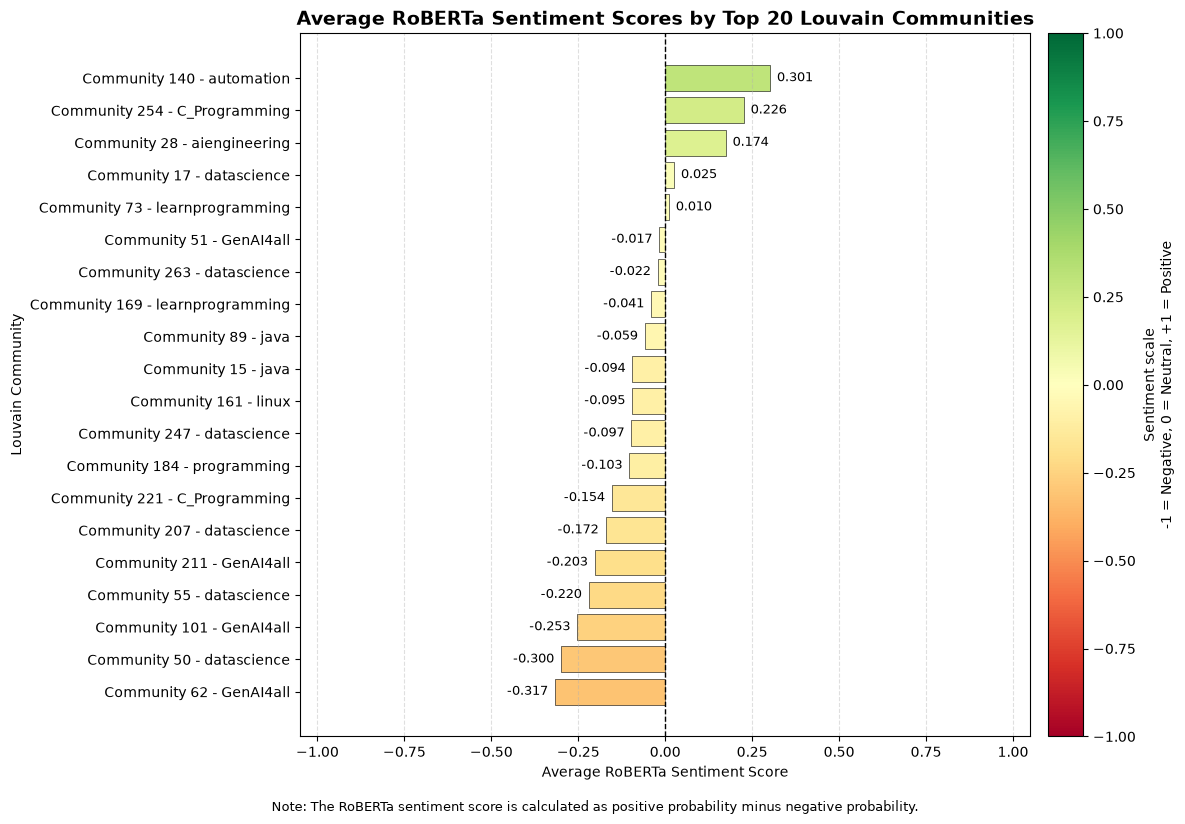

In [38]:
# Plotting the average RoBERTa sentiment score for the top 20 Louvain communities by number of comments

top_community_sentiment = (
    community_sentiment_summary
    .sort_values("number_of_comments", ascending=False)
    .head(20)
)

plot_community_sentiment = (
    top_community_sentiment
    .sort_values("average_sentiment")
)

# RoBERTa sentiment score interpretation:
# Positive probability - Negative probability
# -1 = strongly negative, 0 = neutral/mixed, +1 = strongly positive
sentiment_normalizer = TwoSlopeNorm(
    vmin=-1,
    vcenter=0,
    vmax=1
)

plot_colors = plt.cm.RdYlGn(
    sentiment_normalizer(plot_community_sentiment["average_sentiment"])
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    (
        "Community "
        + plot_community_sentiment["community"].astype(str)
        + " - "
        + plot_community_sentiment["dominant_subreddit"].astype(str)
    ),
    plot_community_sentiment["average_sentiment"],
    color=plot_colors,
    edgecolor="black",
    linewidth=0.4
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color="black"
)

# Adding the score values at the end of each bar
for bar in bars:
    score = bar.get_width()
    y_position = bar.get_y() + bar.get_height() / 2

    if score >= 0:
        text_position = score + 0.02
        horizontal_alignment = "left"
    else:
        text_position = score - 0.02
        horizontal_alignment = "right"

    plt.text(
        text_position,
        y_position,
        f"{score:.3f}",
        va="center",
        ha=horizontal_alignment,
        fontsize=9
    )

plt.title(
    "Average RoBERTa Sentiment Scores by Top 20 Louvain Communities",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average RoBERTa Sentiment Score")
plt.ylabel("Louvain Community")
plt.xlim(-1.05, 1.05)
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Adding colorbar to explain sentiment color scale
sentiment_colorbar = plt.cm.ScalarMappable(
    cmap=plt.cm.RdYlGn,
    norm=sentiment_normalizer
)

sentiment_colorbar.set_array([])

colorbar = plt.colorbar(
    sentiment_colorbar,
    ax=plt.gca(),
    pad=0.02
)

colorbar.set_label(
    "Sentiment scale\n-1 = Negative, 0 = Neutral, +1 = Positive",
    fontsize=10
)

plt.figtext(
    0.5,
    -0.02,
    "Note: The RoBERTa sentiment score is calculated as positive probability minus negative probability.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

### 6.7. TF-IDF keyword analysis

In [39]:
# Creating the TF-IDF vectorizer for identifying important words and phrases
tfidf_keyword_vectorizer = TfidfVectorizer(
    stop_words=english_stop_words,
    max_df=0.90,
    min_df=5,
    ngram_range=(1, 2),
    token_pattern=r"(?u)[A-Za-z0-9_+#]{2,}"
)

# Transforming the cleaned comments into a TF-IDF matrix
tfidf_keyword_matrix = tfidf_keyword_vectorizer.fit_transform(
    nlp_comments["clean_body"]
)

# Getting all TF-IDF terms
tfidf_keyword_terms = tfidf_keyword_vectorizer.get_feature_names_out()

# Calculating the average TF-IDF score for each term
average_tfidf_scores = np.asarray(
    tfidf_keyword_matrix.mean(axis=0)
).ravel()

# Selecting the top 20 TF-IDF keywords for plotting
top_tfidf_keywords = (
    pd.DataFrame({
        "keyword": tfidf_keyword_terms,
        "average_tfidf_score": average_tfidf_scores
    })
    .sort_values("average_tfidf_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)


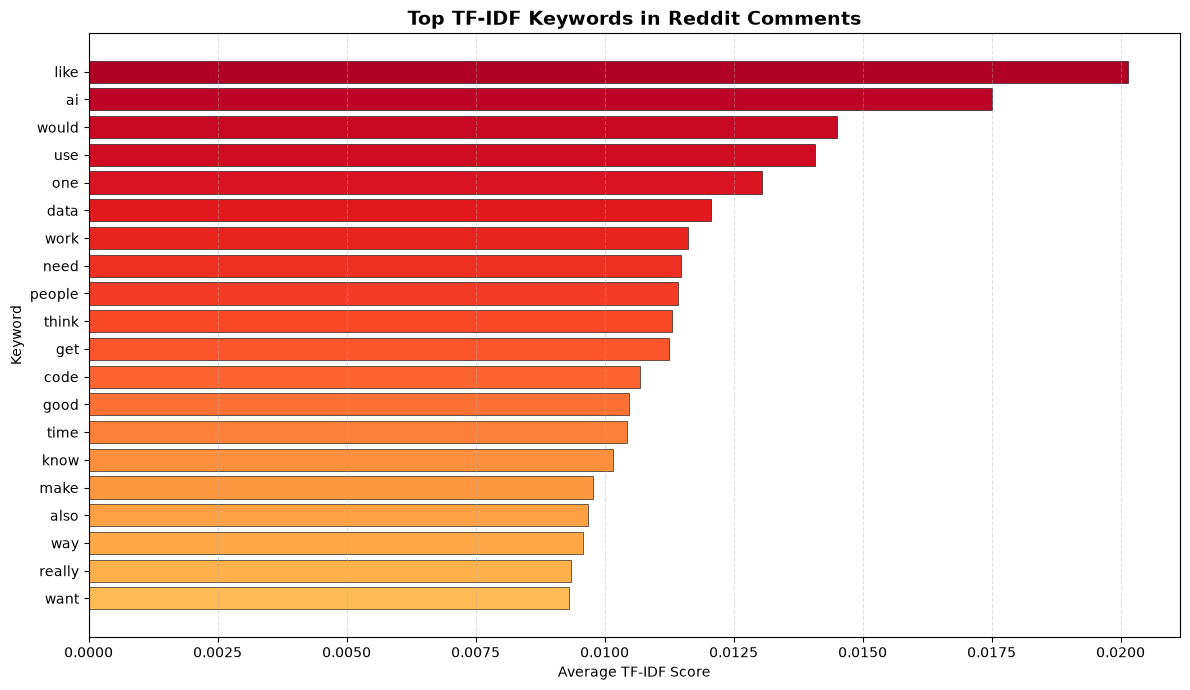

In [40]:
# Plotting the top TF-IDF keywords in Reddit comments

# Preparing the data for horizontal bar chart
plot_tfidf_keywords = (
    top_tfidf_keywords
    .sort_values("average_tfidf_score")
)

# Creating a color gradient for the bars
plot_colors = plt.cm.YlOrRd(
    np.linspace(0.35, 0.90, len(plot_tfidf_keywords))
)

plt.figure(figsize=(12, 7))

plt.barh(
    plot_tfidf_keywords["keyword"],
    plot_tfidf_keywords["average_tfidf_score"],
    color=plot_colors,
    edgecolor="black",
    linewidth=0.4
)

plt.title(
    "Top TF-IDF Keywords in Reddit Comments",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average TF-IDF Score")
plt.ylabel("Keyword")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 6.8. Topic modelling using LDA

In [41]:
# Performing topic modeling using Latent Dirichlet Allocation (LDA)

# Setting the number of topics for LDA
number_of_topics = 6

# Creating the CountVectorizer
lda_vectorizer = CountVectorizer(
    stop_words=english_stop_words,
    max_df=0.90,
    min_df=5,
    max_features=3000,
    ngram_range=(1, 2),
    token_pattern=r"(?u)[A-Za-z0-9_+#]{2,}"
)

# Transforming the cleaned comments into a document-term matrix for LDA
lda_document_term_matrix = lda_vectorizer.fit_transform(
    nlp_comments["clean_body"]
)

# Getting the feature names from the CountVectorizer
lda_terms = lda_vectorizer.get_feature_names_out()

# Fitting the LDA model to the document-term matrix
lda_model = LatentDirichletAllocation(
    n_components=number_of_topics,
    random_state=42,
    learning_method="batch",
    max_iter=20
)

# Calculating the topic probabilities
lda_topic_probabilities = lda_model.fit_transform(
    lda_document_term_matrix
)

# Assigning the dominant topic and its probability
nlp_comments["dominant_topic"] = (
    lda_topic_probabilities.argmax(axis=1) + 1
)

nlp_comments["dominant_topic_probability"] = (
    lda_topic_probabilities.max(axis=1)
)

### 6.9. LDA topic keywords and distribution

In [42]:
# Extracting the top keywords for each LDA topic
topic_keyword_rows = []

for topic_index, topic_word_weights in enumerate(lda_model.components_, start=1):
    top_term_indexes = topic_word_weights.argsort()[-10:][::-1]

    top_keywords = [
        lda_terms[index]
        for index in top_term_indexes
    ]

    topic_keyword_rows.append({
        "topic": topic_index,
        "topic_label": "Topic " + str(topic_index) + ": " + ", ".join(top_keywords[:3]),
        "top_keywords": ", ".join(top_keywords)
    })

topic_keywords = pd.DataFrame(topic_keyword_rows)


# Creating the topic distribution table
topic_distribution = (
    nlp_comments
    .groupby("dominant_topic")
    .agg(
        number_of_comments=("comment_id", "count"),
        average_topic_probability=("dominant_topic_probability", "mean"),
        average_sentiment=("sentiment_score", "mean"),
        positive_percentage=("sentiment_label", lambda labels: sentiment_percentage(labels, "Positive")),
        neutral_percentage=("sentiment_label", lambda labels: sentiment_percentage(labels, "Neutral")),
        negative_percentage=("sentiment_label", lambda labels: sentiment_percentage(labels, "Negative"))
    )
    .reset_index()
    .rename(columns={"dominant_topic": "topic"})
)

topic_distribution = (
    topic_distribution
    .merge(topic_keywords, on="topic", how="left")
    .sort_values("topic", ascending=True)
    .reset_index(drop=True)
)

display(topic_distribution.round(3))

,topic,number_of_comments,average_topic_probability,average_sentiment,positive_percentage,neutral_percentage,negative_percentage,topic_label,top_keywords
0,1,602,0.609,-0.023,18.605,56.645,24.751,"Topic 1: linux, java, windows","linux, java, windows, language, use, programming, one, using, app, system"
1,2,855,0.676,-0.059,10.175,72.047,17.778,"Topic 2: data, use, would","data, use, would, memory, need, like, one, code, also, using"
2,3,1265,0.685,-0.000,25.929,46.957,27.115,"Topic 3: ai, work, time","ai, work, time, job, one, need, good, like, much, would"
3,4,1107,0.693,-0.242,14.905,40.108,44.986,"Topic 4: people, ai, would","people, ai, would, even, code, get, still, one, think, make"
4,5,342,0.677,-0.124,11.696,61.404,26.901,"Topic 5: gt, lt, number","gt, lt, number, would, int, time, main, return, self, range"
5,6,1266,0.683,-0.038,23.618,46.445,29.937,"Topic 6: like, ai, things","like, ai, things, something, really, way, know, see, good, use"


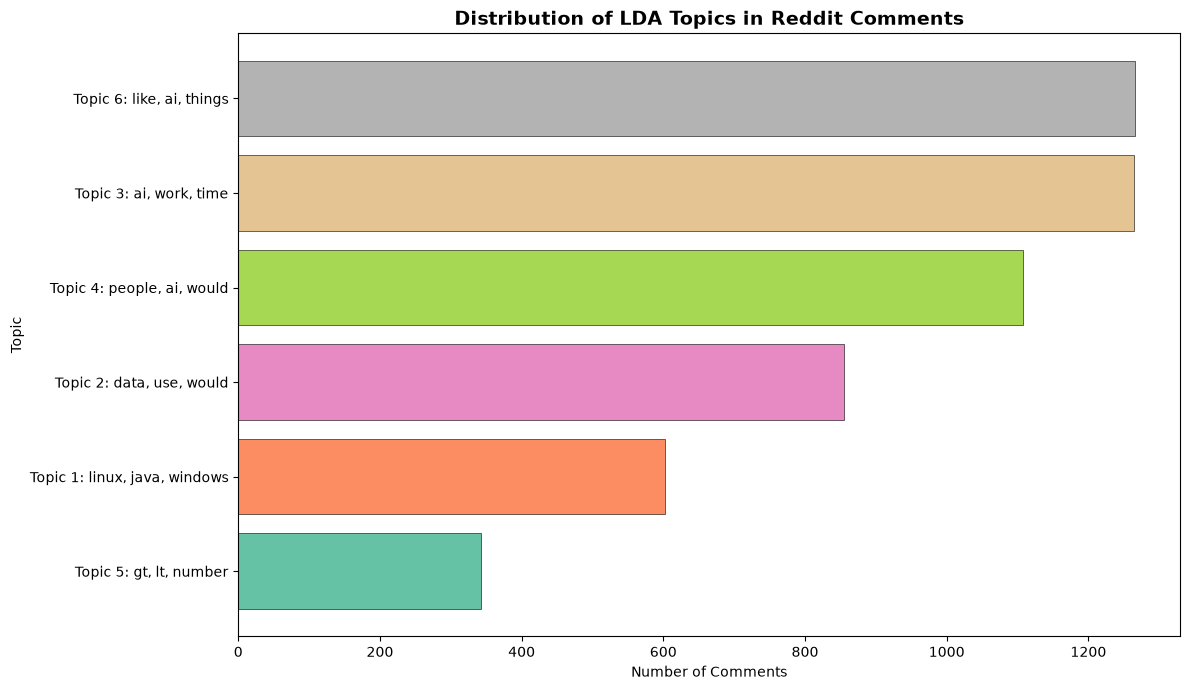

In [43]:
# Plotting the distribution of LDA topics in Reddit comments

plot_topic_distribution = (
    topic_distribution
    .sort_values("number_of_comments")
)

plot_colors = plt.cm.Set2(
    np.linspace(0, 1, len(plot_topic_distribution))
)

plt.figure(figsize=(12, 7))

plt.barh(
    plot_topic_distribution["topic_label"],
    plot_topic_distribution["number_of_comments"],
    color=plot_colors,
    edgecolor="black",
    linewidth=0.4
)

plt.title(
    "Distribution of LDA Topics in Reddit Comments",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Comments")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()

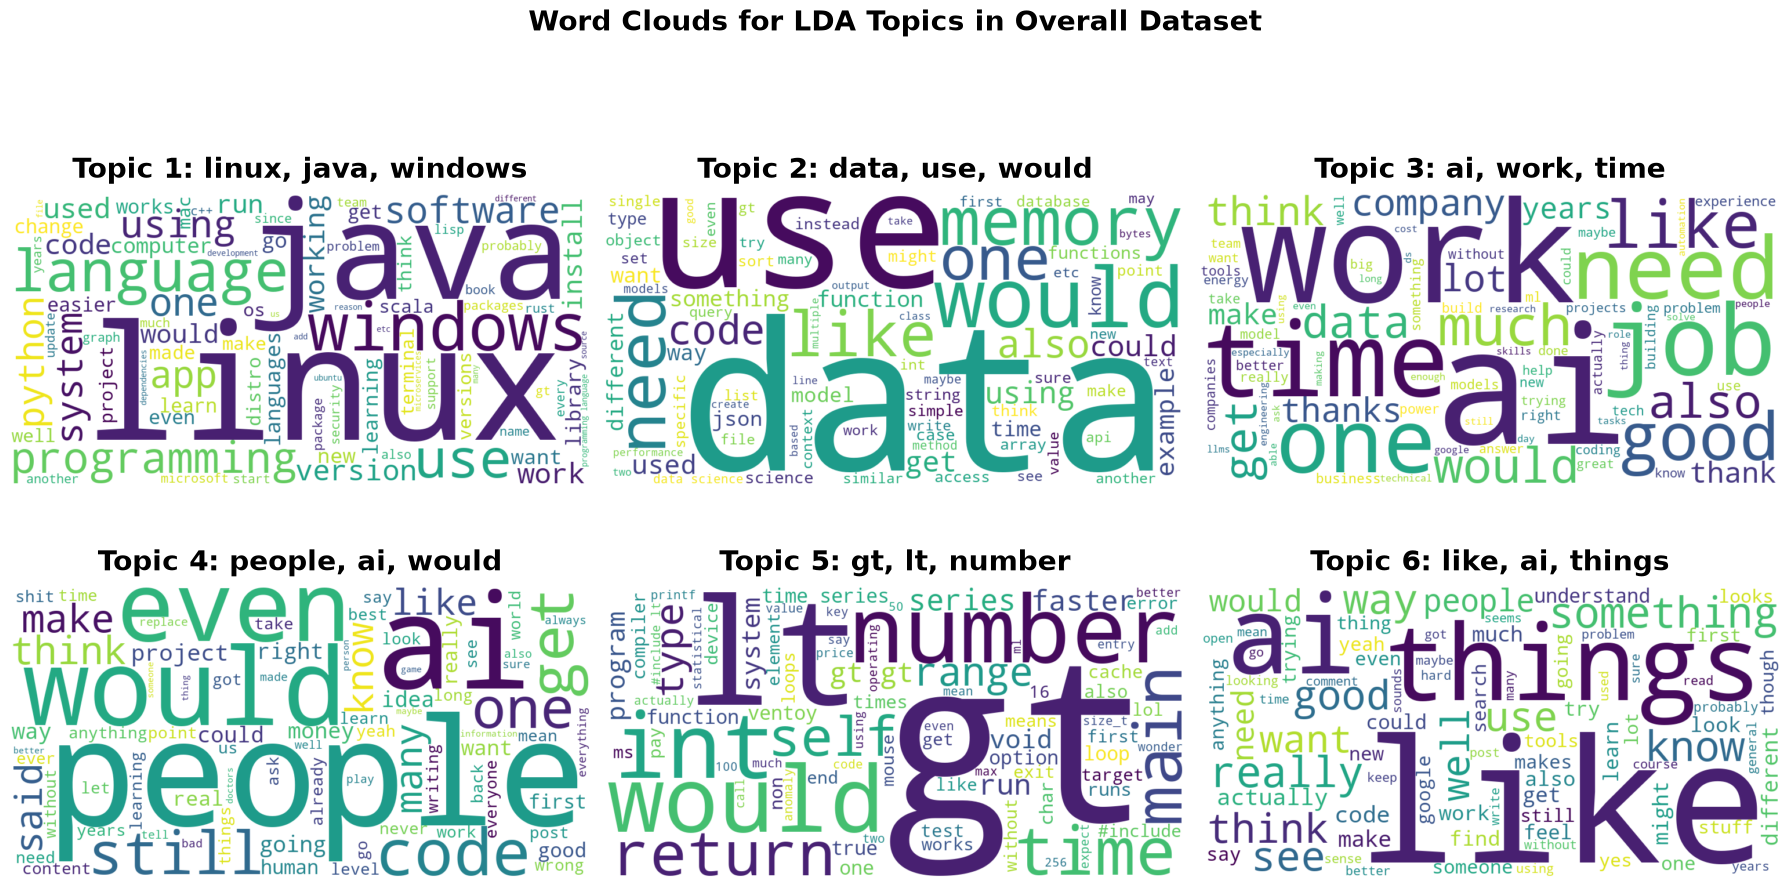

In [44]:
# Plotting word clouds for LDA topics in Reddit comments for the overall dataset

number_of_columns = 3
number_of_rows = math.ceil(number_of_topics / number_of_columns)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(18, 5 * number_of_rows)
)

axes = axes.flatten()

for topic_index, topic_word_weights in enumerate(lda_model.components_):
    topic_word_frequencies = get_topic_word_frequencies(
        topic_word_weights,
        lda_terms,
        top_n=80
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        colormap="viridis",
        max_words=80,
        collocations=False,
        random_state=42
    ).generate_from_frequencies(topic_word_frequencies)

    topic_number = topic_index + 1

    topic_label = topic_keywords.loc[
        topic_keywords["topic"] == topic_number,
        "topic_label"
    ].values[0]

    axes[topic_index].imshow(wordcloud, interpolation="bilinear")
    axes[topic_index].axis("off")
    axes[topic_index].set_title(
        topic_label,
        fontsize=20,
        fontweight="bold",
        pad=12
    )

for empty_axis in axes[number_of_topics:]:
    empty_axis.axis("off")

plt.suptitle(
    "Word Clouds for LDA Topics in Overall Dataset",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 6.10. Community-Level Topic Interpretation

In [45]:
# Analyzing the dominant LDA topics within the detected Louvain communities

# Creating a lookup table
comment_topic_lookup = (
    nlp_comments[["comment_id", "dominant_topic"]]
    .drop_duplicates(subset="comment_id")
)

# Calculating the number of comments for each dominant topic within each community
community_topic_summary = (
    community_sentiment_data
    .merge(
        comment_topic_lookup,
        on="comment_id",
        how="left"
    )
    .groupby(["community", "dominant_topic"])
    .agg(
        number_of_comments=("comment_id", "count")
    )
    .reset_index()
)

# Calculating the total number of comments in each community for percentage calculations
community_total_comments = (
    community_sentiment_data
    .groupby("community")
    .agg(
        community_total_comments=("comment_id", "count")
    )
    .reset_index()
)

# Identifying the dominant topic in each community based on the highest number of comments
dominant_topic_per_community = (
    community_topic_summary
    .sort_values(["community", "number_of_comments"], ascending=[True, False])
    .drop_duplicates(subset="community")
    .rename(columns={
        "dominant_topic": "dominant_topic_in_community",
        "number_of_comments": "dominant_topic_comment_count"
    })
)

# Calculating the percentage of comments in the dominant topic for each community
dominant_topic_per_community = dominant_topic_per_community.merge(
    community_total_comments,
    on="community",
    how="left"
)

# 
dominant_topic_per_community["dominant_topic_percentage"] = (
    dominant_topic_per_community["dominant_topic_comment_count"]
    / dominant_topic_per_community["community_total_comments"]
    * 100
)

dominant_topic_per_community = dominant_topic_per_community.merge(
    topic_keywords.rename(columns={
        "topic": "dominant_topic_in_community",
        "topic_label": "dominant_topic_label",
        "top_keywords": "dominant_topic_keywords"
    }),
    on="dominant_topic_in_community",
    how="left"
)

community_nlp_summary = (
    community_sentiment_summary
    .merge(
        dominant_topic_per_community,
        on="community",
        how="left"
    )
    .sort_values("number_of_comments", ascending=False)
)

display(community_nlp_summary.head().round(3))

,community,number_of_comments,number_of_users,average_sentiment,positive_percentage,neutral_percentage,negative_percentage,community_label,dominant_subreddit,top_keywords,dominant_topic_in_community,dominant_topic_comment_count,community_total_comments,dominant_topic_percentage,dominant_topic_label,dominant_topic_keywords
0,89,238,87,-0.059,15.966,58.824,25.210,Community 89 - java interaction group,java,"java, code, python, string, optional, zgc, language, null, json, hashcode",6,83,238,34.874,"Topic 6: like, ai, things","like, ai, things, something, really, way, know, see, good, use"
1,51,222,85,-0.017,25.676,41.441,32.883,Community 51 - GenAI4all interaction group,GenAI4all,"ai, chip, ironwood, doctor, google, ai tool, content, haha, sounds, totally",4,69,222,31.081,"Topic 4: people, ai, would","people, ai, would, even, code, get, still, one, think, make"
2,184,197,96,-0.103,16.244,50.761,32.995,Community 184 - programming interaction group,programming,"100k, url, handle, urls, aws, database, ve, code, tables, distributed",2,41,197,20.812,"Topic 2: data, use, would","data, use, would, memory, need, like, one, code, also, using"
3,161,167,73,-0.095,19.162,47.305,33.533,Community 161 - linux interaction group,linux,"linux, ventoy, windows, usb, distro, roblox, ubuntu, install, boot, iso",1,61,167,36.527,"Topic 1: linux, java, windows","linux, java, windows, language, use, programming, one, using, app, system"
4,15,138,62,-0.094,16.667,52.174,31.159,Community 15 - java interaction group,java,"memory, java, scala, zgc, heap, xx, code, container, data structures, operation",6,46,138,33.333,"Topic 6: like, ai, things","like, ai, things, something, really, way, know, see, good, use"


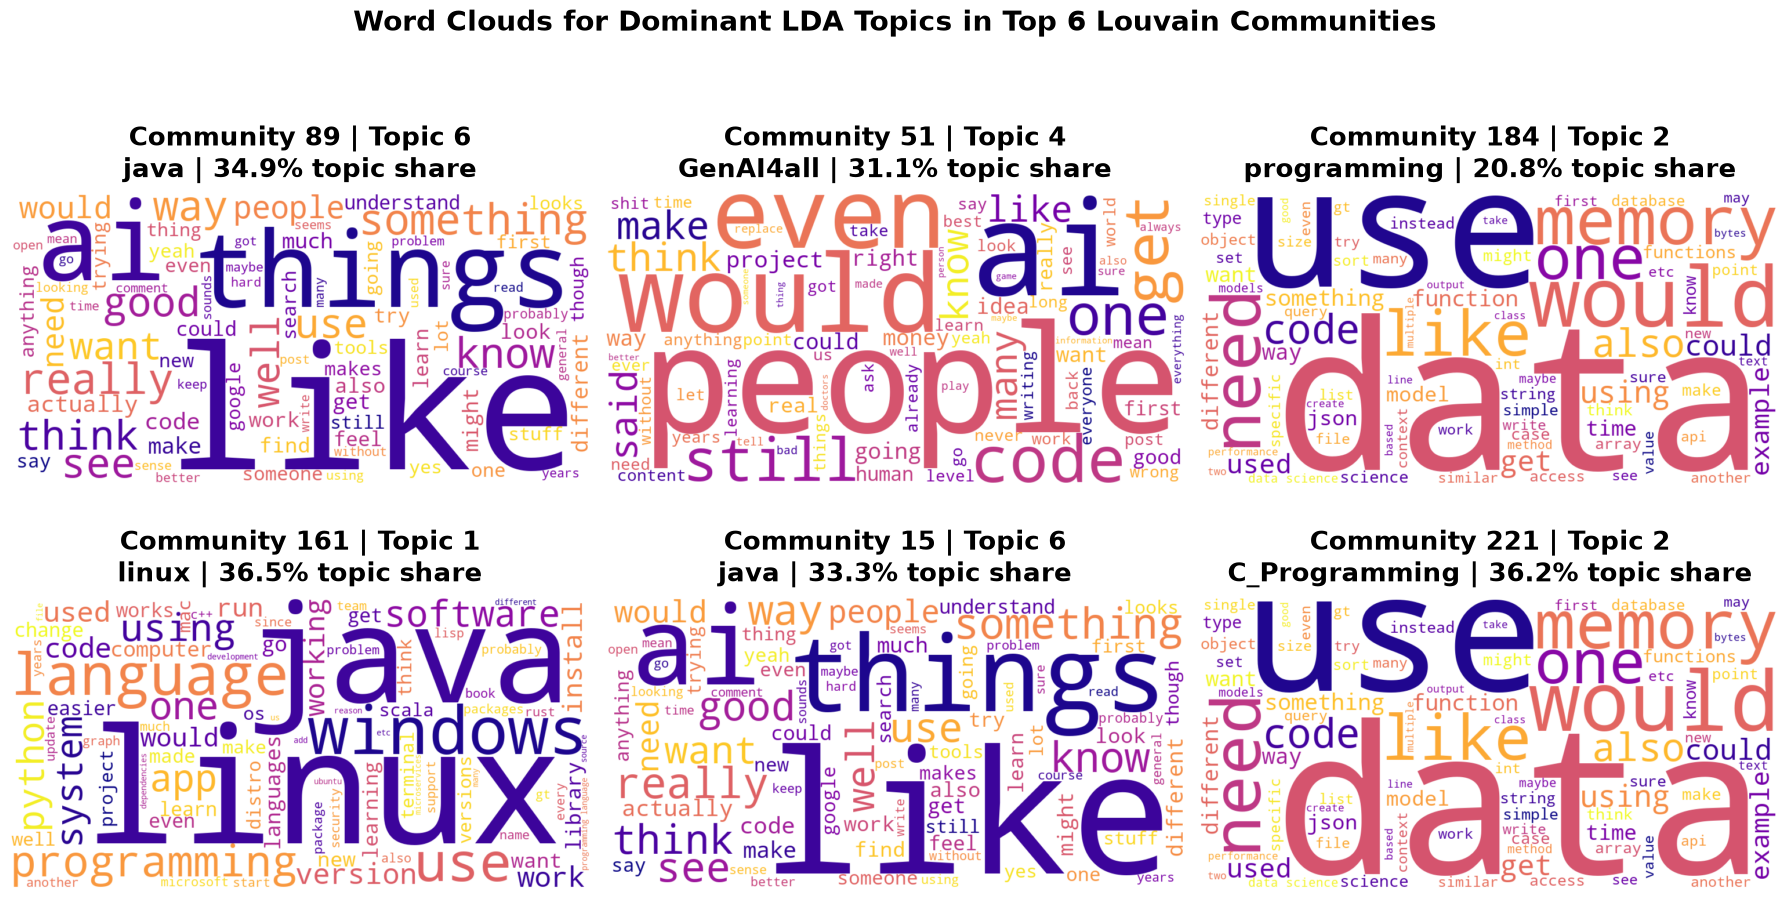

In [46]:
# Plotting the word clouds for the dominant LDA topic in the top 6 Louvain communities by number of comments

top_topic_communities = (
    community_nlp_summary
    .dropna(subset=["dominant_topic_in_community"])
    .sort_values("number_of_comments", ascending=False)
    .head(6)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for index, row in top_topic_communities.iterrows():
    community_id = int(row["community"])
    dominant_topic = int(row["dominant_topic_in_community"])
    dominant_subreddit = row["dominant_subreddit"]
    dominant_topic_percentage = row["dominant_topic_percentage"]

    topic_word_frequencies = get_topic_word_frequencies(
        lda_model.components_[dominant_topic - 1],
        lda_terms,
        top_n=80
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        colormap="plasma",
        max_words=80,
        collocations=False,
        random_state=42
    ).generate_from_frequencies(topic_word_frequencies)

    axes[index].imshow(wordcloud, interpolation="bilinear")
    axes[index].axis("off")
    axes[index].set_title(
        f"Community {community_id} | Topic {dominant_topic}\n"
        f"{dominant_subreddit} | {dominant_topic_percentage:.1f}% topic share",
        fontsize=19,
        fontweight="bold",
        pad=12
    )

for empty_axis in axes[len(top_topic_communities):]:
    empty_axis.axis("off")

plt.suptitle(
    "Word Clouds for Dominant LDA Topics in Top 6 Louvain Communities",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 7. Final Results, Interpretation, Limitations, and Conclusion

### 7.1 Key Results

<div style="text-align: justify">

This project analyzed Reddit technology and programming comments using both network analysis and NLP/text analysis. The final cleaned dataset contained **5,437 comments** from **28 subreddits** and **3,103 unique authors**. The data was collected from technology, programming, artificial intelligence, data science, cybersecurity, Linux, and software development-related Reddit communities.

A directed weighted user reply network was constructed using comment-to-comment reply relationships. In this network, each node represented a Reddit user, and each directed edge represented one user replying to another user. The final reply network contained **1,692 users**, **1,991 directed weighted reply relationships**, and **2,366 total reply interactions**. The network density was **0.000696**, showing that the Reddit reply network was sparse.

Centrality analysis was used to identify different types of important users. Weighted in-degree identified users who received many replies, weighted out-degree identified users who actively replied to others, PageRank identified structurally influential users, and betweenness centrality identified bridge users connecting different parts of the network.

Louvain community detection identified **278 communities** in the user reply network, with a modularity score of **0.953**. This high modularity score indicates that the network contained clearly separated interaction groups. The largest communities were linked to subreddits and topics such as `programming`, `java`, `GenAI4all`, and `linux`.

For sentiment analysis, both VADER and RoBERTa were applied. VADER classified **55.141%** of comments as positive, **21.979%** as neutral, and **22.880%** as negative. RoBERTa classified **18.963%** of comments as positive, **51.370%** as neutral, and **29.667%** as negative. RoBERTa was used as the main sentiment model because it provides better contextual interpretation for technical and discussion-based text.

TF-IDF keyword analysis showed important terms such as `ai`, `data`, `code`, `work`, `people`, `use`, and `time`, confirming that the dataset was strongly related to technology and programming discussion. LDA topic modeling identified six major topics across the comments. These topics included themes related to Linux, Java, Windows, data, AI, work, people, code, and programming-related text patterns.

Community-level NLP analysis showed that Louvain communities were connected to different dominant LDA topics and sentiment patterns. For example, Linux-related communities were linked to topics involving `linux`, `java`, `windows`, and programming terms, while AI-related communities were linked to broader discussion around `people`, `ai`, `would`, and `code`.
</div>

### 7.2 Interpretation

<div style="text-align: justify">

The results show that Reddit technology and programming discussions form a sparse but meaningful user interaction network. Most users interacted with only a small number of other users, which is expected in Reddit discussions because conversations usually occur within specific posts, threads, or smaller sub-discussions.

The centrality results show that user importance is not the same for every metric. Some users were important because they received many replies, while others were important because they actively replied to others. Bridge users were also important because they connected different parts of the network, even if they were not always the most replied-to users.

The Louvain community detection results show that Reddit discussions were organized into many smaller interaction communities. These communities were often connected to particular subreddits or technical themes. This suggests that Reddit technology communities are not one single connected discussion space, but instead consist of multiple smaller groups formed around specific topics, threads, or interactions.

The sentiment results show that RoBERTa classified most comments as neutral. This is reasonable because technology and programming discussions are often explanatory, instructional, or problem-focused rather than strongly emotional. Negative sentiment appeared in discussions involving criticism, disagreement, troubleshooting, technical problems, or debate. Positive sentiment appeared in more supportive, helpful, or constructive discussions.

The LDA topic results show that the dataset contained multiple discussion themes rather than one dominant topic. These themes included artificial intelligence, programming languages, operating systems, data-related work, code-like text, and general technology discussion. The combination of LDA topics with Louvain communities showed that network communities had identifiable discussion themes, meaning the communities were not only structural clusters but also meaningful content-based groups.

Overall, the project shows that combining network analysis with NLP provides a stronger understanding of Reddit discussions. Network analysis explains how users interact, while NLP explains what users discuss and what sentiment appears in those discussions.
</div>

### 7.3 Limitations

<div style="text-align: justify">

There are several limitations in this analysis. First, the dataset was collected from selected technology and programming-related subreddits only. Therefore, the results may not represent all Reddit communities or all technology-related discussions on Reddit.

Second, the dataset was collected using the PullPush Reddit API, which may not capture every Reddit post or comment. Some comments may have been deleted, removed, unavailable, or missed during data collection. Therefore, the dataset should be understood as a collected sample rather than a complete representation of Reddit activity.

Third, the dataset was not evenly distributed across all subreddits. Some subreddits, such as `GenAI4all`, `datascience`, `java`, `technology`, and `linux`, contributed many more comments than smaller subreddits such as `CyberCrime` and `coding`. This imbalance may influence the overall sentiment and topic modeling results.

Fourth, sentiment analysis has limitations. Although RoBERTa is more context-aware than VADER, it may still misclassify sarcasm, jokes, informal language, technical disagreement, or code-related comments. Reddit comments often contain abbreviations, technical terms, and conversational language, which can affect sentiment classification.

Fifth, Louvain community detection was applied to a sparse reply network. While the modularity score was high, some detected communities may represent small thread-level clusters rather than stable long-term communities. Therefore, the communities should be interpreted as interaction communities within this collected dataset, not as permanent Reddit communities.
</div>

### 7.4 Conclusion

<div style="text-align: justify">

This project successfully analyzed Reddit technology and programming comments using a combination of network analysis and NLP/text analysis. The reply network analysis identified central users, active users, bridge users, and Louvain communities. The NLP analysis identified sentiment patterns, important keywords, and LDA topics across the cleaned Reddit comments.

The results showed that Reddit technology and programming discussions were mostly neutral in sentiment, which reflects the technical and informational nature of these communities. The topic modeling results showed that discussions covered artificial intelligence, programming languages, operating systems, data, code, and broader technology issues.

The integrated community-level analysis showed that Louvain communities were connected to identifiable topics and sentiment patterns. This means that the detected communities were not only network-based clusters, but also meaningful discussion groups with specific textual themes.

Overall, the analysis demonstrates that combining social network analysis with NLP provides a deeper understanding of online Reddit communities. Network analysis shows how users interact, while NLP analysis shows what they discuss and how sentiment varies across those discussions. Future work could extend this analysis by collecting data over a longer time period, comparing individual subreddit networks, using more advanced topic modeling methods such as BERTopic, or analyzing how sentiment and topics change over time.
</div>